<a href="https://colab.research.google.com/github/sudo-ansh007/forecast/blob/main/win_probability_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to read this notebook

It was built in layers, and later sections **supersede** earlier ones. Read in this order:

| Section | Status |
|---|---|
| **§9 + §10 (bottom)** | **Current.** The shipping model, its eval, and the plots. Start here. |
| §1–§8 | Diagnostics. Mostly *negative* results — kept as evidence, not as recommendations. |
| Cells 1–60 (top) | Model selection (XGBoost vs CatBoost vs LightGBM) and threshold work. Conclusions still hold; **their headline metric does not.** |

**The single most important thing:** every number in the top sections comes from one
20% chronological test slice — 715 deals, 79 wins, PR_AUC ≈ 0.586, ±0.10 CI. That slice
landed on the most right-censored window in the timeline, so it *understates* the model.
The reported eval is now **walk-forward: PR_AUC 0.714, ROC 0.932** (§9). Same model, honest
measurement. Do not quote 0.586.

**Also superseded at the top:** `train.parquet` now derives meeting timing from
`dim_meeting.scheduled_date` (when meetings were *held*), not `dim_link.created_date`
(when the link row was *ingested*). See §9 — this was a real defect, and fixing it is the
only change in the whole investigation that beat the noise floor.

Shipping config lives in `train_model.py`, not in this notebook. Cells here write to
`models_notebook/`; production artifacts are in `models/`.

In [130]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss, accuracy_score, precision_score, recall_score, f1_score)


In [131]:
# train.parquet, not ml_train.csv -- the CSV predates the scheduled_date fix
# (meeting timing from link ingest dates) and lacks the velocity columns.
train = pd.read_parquet("train.parquet").sort_values("created_date").reset_index(drop=True)
train.head()

,log_acv,acv_missing,days_in_current_stage,days_in_sales_cycle,stall_ratio,contract_months,num_stakeholders,has_champion,poc,opportunity_type,...,display_id,stage_name,rep_id,account_id,created_date,target_close_date,actual_close_date,acv,state,is_won
0,9.092007,0,13.0,78.5,0.165605,12.0,0,0,0,new,...,OPP-102,8-closed_won,don:identity:dvrv-us-1:devo/0:devu/130,don:identity:dvrv-us-1:devo/0:account/bhjtKSno,2023-01-12,2024-01-28,2024-01-28,8883.0,closed,1
1,9.950610,0,13.0,78.5,0.165605,12.0,1,1,0,new,...,OPP-246,8-closed_won,don:identity:dvrv-us-1:devo/0:devu/766,don:identity:dvrv-us-1:devo/0:account/K4b82SL4,2023-02-20,2024-01-31,2024-01-31,20964.0,closed,1
2,8.192847,0,13.0,78.5,0.165605,12.0,0,0,0,new,...,OPP-234,8-closed_won,don:identity:dvrv-us-1:devo/0:devu/761,don:identity:dvrv-us-1:devo/0:account/KL0fLY1w,2023-04-01,2024-02-01,2024-02-01,3614.0,closed,1
3,10.507722,0,13.0,78.5,0.165605,12.0,1,1,0,new,...,OPP-214,8-closed_won,don:identity:dvrv-us-1:devo/0:devu/766,don:identity:dvrv-us-1:devo/0:account/I2Q151rj,2023-04-01,2024-01-19,2024-01-19,36596.0,closed,1
4,9.984514,0,13.0,78.5,0.165605,12.0,2,1,0,new,...,OPP-216,8-closed_won,don:identity:dvrv-us-1:devo/0:devu/766,don:identity:dvrv-us-1:devo/0:account/lv2gdlvo,2023-04-01,2024-01-24,2024-01-24,21687.0,closed,1


In [132]:
BASE13 = ["days_in_current_stage", "days_in_sales_cycle", "stall_ratio", "contract_months",
          "num_stakeholders", "has_champion", "poc", "opportunity_type", "source", "geo",
          "segment", "number_of_meetings", "days_since_latest_meeting"]
MEETING_VELOCITY = ["meetings_first_30d", "meetings_per_month", "meeting_quiet_frac"]
FEATURES = BASE13 + MEETING_VELOCITY          # 16 -- matches train_model.py
CATEGORICALS = ["opportunity_type", "source", "geo", "segment"]

print(len(train), "deals", train.is_won.sum(), "won")
print("features:", len(FEATURES))

3573 deals 541 won
features: 16


In [133]:
num = [f for f in FEATURES if f not in CATEGORICALS]
X = train[num].astype(float)
for c in CATEGORICALS:
    X = pd.concat([X, pd.get_dummies(train[c], prefix=c, dtype=float)], axis=1)

# segment-specific patterns: let each segment learn its own slope on the features
# that matter most (from the permutation-importance run below), instead of one
# shared slope across enterprise/mid-market/smb/start-up.
INTERACT_WITH = ["days_in_current_stage", "stall_ratio", "contract_months"]
seg_dum = pd.get_dummies(train.segment, prefix="seg_x", dtype=float)
for s in seg_dum.columns:
    for f in INTERACT_WITH:
        X[f"{s}__{f}"] = seg_dum[s] * train[f]

y = train.is_won.to_numpy()

cut = int(len(train) * 0.8)
X_train, X_test, y_train, y_test = X[:cut], X[cut:], y[:cut], y[cut:]
print(f"train {len(y_train)}/{y_train.sum()} won   test {len(y_test)}/{y_test.sum()} won")


train 2858/462 won   test 715/79 won


In [134]:
model = CalibratedClassifierCV(XGBClassifier(max_depth=3, n_estimators=200, learning_rate=0.05, min_child_weight=1, random_state=0, eval_metric="logloss"), method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0)).fit(X_train, y_train)

p_train = model.predict_proba(X_train)[:,1]
p_test = model.predict_proba(X_test)[:,1]


In [135]:
def m(yy, pp):
    return {"n": len(yy), "wins": yy.sum(), "base": yy.mean(), "PR_AUC": average_precision_score(yy, pp), "lift": average_precision_score(yy, pp) / yy.mean(), "ROC": roc_auc_score(yy, pp), "Brier": brier_score_loss(yy, pp), "sum_p/act": pp.sum() / yy.sum()}

print(pd.DataFrame({"train": m(y_train, p_train), "test": m(y_test, p_test), "no model": m(y_test, np.full(len(y_test), y_train.mean()))}).T.to_string(float_format=lambda v: f"{v:.4f}"))


                 n     wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
train    2858.0000 462.0000 0.1617  0.9343 5.7794 0.9813 0.0370     1.0007
test      715.0000  79.0000 0.1105  0.6524 5.9045 0.8906 0.0681     1.1618
no model  715.0000  79.0000 0.1105  0.1105 1.0000 0.5000 0.1009     1.4630


In [136]:
rows = []
for th in (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1):
    yp = (p_test >= th).astype(int)
    rows.append({"Threshold": th, "accuracy": accuracy_score(y_test, yp), "precision": precision_score(y_test, yp, zero_division=0), "recall": recall_score(y_test, yp), "F1": f1_score(y_test, yp), "Found": yp[y_test == 1].sum()})
print(f"always-lose accuracy: {1-y_test.mean():.3f}, finds 0 of {y_test.sum()}\n") 
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v:f"{v:.3f}"))


always-lose accuracy: 0.890, finds 0 of 79

 Threshold  accuracy  precision  recall    F1  Found
     0.700     0.923      0.740   0.468 0.574     37
     0.600     0.910      0.619   0.494 0.549     39
     0.500     0.908      0.594   0.519 0.554     41
     0.400     0.899      0.543   0.557 0.550     44
     0.300     0.894      0.516   0.608 0.558     48
     0.200     0.894      0.514   0.684 0.587     54
     0.100     0.866      0.436   0.734 0.547     58


## Threshold 0.4 here — superseded, production uses 0.3

0.4 was chosen against the *uncalibrated* XGBoost above and is kept so the
model-family comparison below stays internally consistent. After sigmoid
calibration the operating point moved: production threshold is **0.3**
(`FINAL_CONFIG`, and `threshold` in `models/model_metadata.pkl`).

In [137]:
def rec(yy, pp, f):
    k = int(len(pp) * f)
    return yy[np.argsort(pp)[::-1][:k]].sum() / yy.sum()

print(pd.DataFrame([{"top": f, "train": rec(y_train, p_train, f), "test": rec(y_test,p_test, f), "random": f, "lift": rec(y_test, p_test, f) / f}for f in (0.05, 0.1, 0.2, 0.3, 0.5)]).to_string(index=False, float_format=lambda v: f"{v:.3f}"))


  top  train  test  random  lift
0.050  0.307 0.342   0.050 6.835
0.100  0.608 0.519   0.100 5.190
0.200  0.903 0.747   0.200 3.734
0.300  0.983 0.835   0.300 2.785
0.500  0.996 0.899   0.500 1.797


In [138]:
EDGES = [0, .05, .10, .20, .40, .60, .80, 1.01]

def rel(yy, pp):
    out = []
    for lo, hi in zip(EDGES, EDGES[1:]):
        s = (pp >= lo) & (pp < hi)
        if s.sum():
            out.append({"bin": f"{lo:.0%}-{min(hi,1):.0%}", "deals": s.sum(),
                        "predicted": pp[s].mean(), "actual": yy[s].mean(),
                        "err": yy[s].mean() - pp[s].mean()})
    return pd.DataFrame(out)

print(rel(y_test, p_test).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\naggregate: predicted {p_test.mean():.4f} vs actual {y_test.mean():.4f}")


     bin  deals  predicted  actual     err
   0%-5%    525     0.0305  0.0248 -0.0057
  5%-10%     57     0.0683  0.1404  0.0720
 10%-20%     28     0.1372  0.1429  0.0056
 20%-40%     24     0.3074  0.4167  0.1093
 40%-60%     18     0.4826  0.2778 -0.2048
 60%-80%     23     0.6995  0.3043 -0.3952
80%-100%     40     0.8970  0.8000 -0.0970

aggregate: predicted 0.1284 vs actual 0.1105


In [139]:
from sklearn.inspection import permutation_importance
imp = permutation_importance(model, X_test, y_test, scoring="average_precision",
                            n_repeats=10, random_state=0)
print(pd.DataFrame({"feature": X.columns, "drop": imp.importances_mean})
    .sort_values("drop", ascending=False).head(12)
    .to_string(index=False, float_format=lambda v: f"{v:.4f}"))

                      feature   drop
        days_in_current_stage 0.1948
                  stall_ratio 0.1219
              contract_months 0.0699
                          poc 0.0262
         opportunity_type_new 0.0239
    days_since_latest_meeting 0.0168
           meeting_quiet_frac 0.0161
          days_in_sales_cycle 0.0098
                     geo_amer 0.0089
             num_stakeholders 0.0077
           meetings_per_month 0.0076
seg_x_mid-market__stall_ratio 0.0052


In [140]:
from sklearn.model_selection import cross_val_predict
p_oof = cross_val_predict(
    CalibratedClassifierCV(
        XGBClassifier(max_depth=3, n_estimators=200, learning_rate=0.05,
                    min_child_weight=1, random_state=0,
eval_metric="logloss"),
        method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0)),
    X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=0),
    method="predict_proba")[:, 1]

a_in, a_oof, a_te = (average_precision_score(y_train, p_train),
                    average_precision_score(y_train, p_oof),
                    average_precision_score(y_test, p_test))
print(f"in-sample {a_in:.4f} -> OOF {a_oof:.4f}   gap {a_in-a_oof:+.4f} overfitting")
print(f"OOF {a_oof:.4f} -> test {a_te:.4f}   gap {a_oof-a_te:+.4f} distribution shift")


in-sample 0.9343 -> OOF 0.8644   gap +0.0698 overfitting
OOF 0.8644 -> test 0.6524   gap +0.2120 distribution shift


## Segment breakdown — base rates differ a lot, so check if the model tracks each one


In [141]:
seg_test = train.segment.iloc[cut:].reset_index(drop=True)

def seg_report(seg, yy, pp):
    rows = []
    for s in seg.unique():
        m_ = seg == s
        yys, pps = yy[m_.to_numpy()], pp[m_.to_numpy()]
        if yys.sum() == 0 or yys.sum() == len(yys):
            rows.append({"segment": s, "n": len(yys), "wins": yys.sum(), "base": yys.mean(),
                        "PR_AUC": np.nan, "ROC": np.nan, "note": "no variance in y"})
            continue
        rows.append({"segment": s, "n": len(yys), "wins": yys.sum(), "base": yys.mean(),
                    "PR_AUC": average_precision_score(yys, pps), "ROC": roc_auc_score(yys, pps), "note": ""})
    return pd.DataFrame(rows).sort_values("n", ascending=False)

print("train base rates by segment:")
print(train.groupby("segment").is_won.agg(n="count", wins="sum", base="mean").sort_values("n", ascending=False).to_string(float_format=lambda v: f"{v:.4f}"))
print("\ntest performance by segment:")
print(seg_report(seg_test, y_test, p_test).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


train base rates by segment:
               n  wins   base
segment                      
enterprise  1205   107 0.0888
mid-market   909   128 0.1408
smb          663    96 0.1448
start-up     652   209 0.3206
unknown      122     0 0.0000
2k            22     1 0.0455

test performance by segment:
   segment   n  wins   base  PR_AUC    ROC             note
enterprise 308    19 0.0617  0.6010 0.8769                 
mid-market 170    23 0.1353  0.7254 0.8965                 
       smb 109    12 0.1101  0.6597 0.9149                 
  start-up  93    24 0.2581  0.7517 0.8134                 
        2k  18     1 0.0556  0.3333 0.8824                 
   unknown  17     0 0.0000     NaN    NaN no variance in y


## Hyperparameter tuning — search XGBoost params for best CV average-precision


In [142]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_depth": [2, 3, 4, 5],
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.02, 0.05, 0.08, 0.1],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.5, 1, 2, 5],
}
search = RandomizedSearchCV(
    XGBClassifier(random_state=0, eval_metric="logloss"),
    param_dist, n_iter=40, scoring="average_precision",
    cv=StratifiedKFold(5, shuffle=True, random_state=0), random_state=0, n_jobs=-1,
).fit(X_train, y_train)

print(f"best CV PR_AUC: {search.best_score_:.4f}\n")
print(pd.Series(search.best_params_, name="best_value").to_string())


best CV PR_AUC: 0.8687

subsample             0.8
reg_lambda            2.0
n_estimators        100.0
min_child_weight      1.0
max_depth             3.0
learning_rate         0.1
colsample_bytree      0.6


In [143]:
tuned = CalibratedClassifierCV(
    XGBClassifier(random_state=0, eval_metric="logloss", **search.best_params_),
    method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0),
).fit(X_train, y_train)

p_train_t = tuned.predict_proba(X_train)[:, 1]
p_test_t = tuned.predict_proba(X_test)[:, 1]
p_oof_t = cross_val_predict(
    CalibratedClassifierCV(
        XGBClassifier(random_state=0, eval_metric="logloss", **search.best_params_),
        method="sigmoid", cv=StratifiedKFold(3, shuffle=True, random_state=0),
    ), X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba",
)[:, 1]

print(pd.DataFrame({
    "baseline": m(y_test, p_test),
    "tuned+segment_interactions": m(y_test, p_test_t),
}).T.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\ntuned OOF {average_precision_score(y_train, p_oof_t):.4f} -> test {average_precision_score(y_test, p_test_t):.4f}"
    f"   gap {average_precision_score(y_train, p_oof_t) - average_precision_score(y_test, p_test_t):+.4f}")


                                  n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
baseline                   715.0000 79.0000 0.1105  0.6524 5.9045 0.8906 0.0681     1.1618
tuned+segment_interactions 715.0000 79.0000 0.1105  0.6424 5.8138 0.8908 0.0705     1.1492

tuned OOF 0.8685 -> test 0.6424   gap +0.2261


## Model family comparison — same chronological split, CatBoost/LightGBM handle categoricals natively


In [144]:
from catboost import CatBoostClassifier

Xraw = train[FEATURES].copy()
for c in CATEGORICALS:
    Xraw[c] = Xraw[c].astype(str)
Xr_train, Xr_test = Xraw[:cut], Xraw[cut:]
cat_idx = [Xraw.columns.get_loc(c) for c in CATEGORICALS]

catboost_model = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.05, random_state=0, verbose=False, cat_features=cat_idx,
).fit(Xr_train, y_train)
p_test_cb = catboost_model.predict_proba(Xr_test)[:, 1]

print(pd.Series(m(y_test, p_test_cb)).to_string())


n            715.000000
wins          79.000000
base           0.110490
PR_AUC         0.642937
lift           5.818989
ROC            0.898674
Brier          0.066537
sum_p/act      1.210108


In [145]:
from lightgbm import LGBMClassifier

Xl_train, Xl_test = Xr_train.copy(), Xr_test.copy()
for c in CATEGORICALS:
    Xl_train[c] = Xl_train[c].astype("category")
    Xl_test[c] = Xl_test[c].astype("category").cat.set_categories(Xl_train[c].cat.categories)

lgbm_model = LGBMClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, random_state=0, verbosity=-1,
).fit(Xl_train, y_train)
p_test_lgbm = lgbm_model.predict_proba(Xl_test)[:, 1]

print(pd.Series(m(y_test, p_test_lgbm)).to_string())


n            715.000000
wins          79.000000
base           0.110490
PR_AUC         0.620203
lift           5.613233
ROC            0.890574
Brier          0.070757
sum_p/act      1.105633


## Comparison — XGBoost vs CatBoost vs LightGBM, same test set


In [146]:
TH = 0.4  # from the threshold table above

def m2(yy, pp, th=TH):
    yp = (pp >= th).astype(int)
    d = m(yy, pp)
    d["accuracy"] = accuracy_score(yy, yp)
    d["precision"] = precision_score(yy, yp, zero_division=0)
    d["recall"] = recall_score(yy, yp)
    d["F1"] = f1_score(yy, yp)
    return d

comparison = pd.DataFrame({
    "XGBoost (tuned+segment)": m2(y_test, p_test_t),
    "CatBoost": m2(y_test, p_test_cb),
    "LightGBM": m2(y_test, p_test_lgbm),
}).T
print(comparison.to_string(float_format=lambda v: f"{v:.4f}"))


                               n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act  accuracy  precision  recall     F1
XGBoost (tuned+segment) 715.0000 79.0000 0.1105  0.6424 5.8138 0.8908 0.0705     1.1492    0.8993     0.5443  0.5443 0.5443
CatBoost                715.0000 79.0000 0.1105  0.6429 5.8190 0.8987 0.0665     1.2101    0.8979     0.5341  0.5949 0.5629
LightGBM                715.0000 79.0000 0.1105  0.6202 5.6132 0.8906 0.0708     1.1056    0.8965     0.5287  0.5823 0.5542


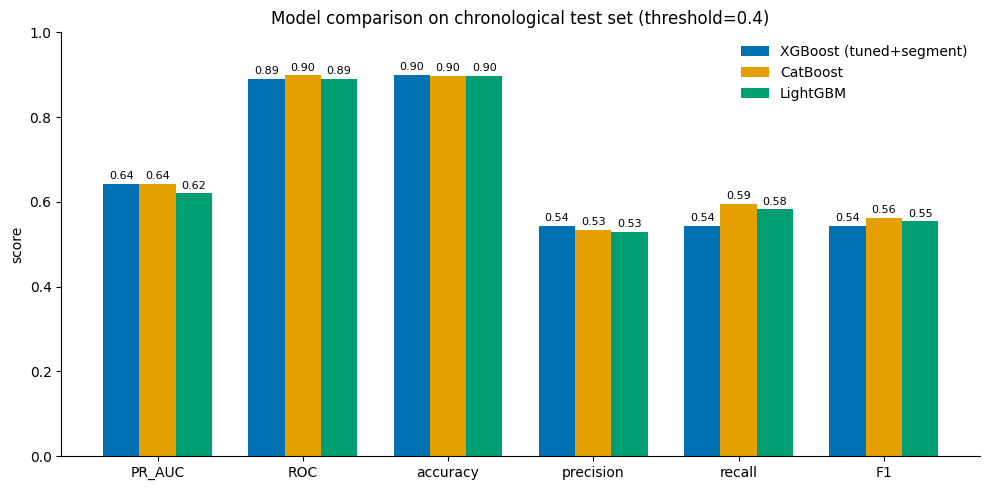

In [147]:
import matplotlib.pyplot as plt

METRICS = ["PR_AUC", "ROC", "accuracy", "precision", "recall", "F1"]
COLORS = ["#0072B2", "#E69F00", "#009E73"]  # Okabe-Ito, colorblind-safe

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(METRICS))
width = 0.25
for i, (model_name, color) in enumerate(zip(comparison.index, COLORS)):
    vals = comparison.loc[model_name, METRICS].to_numpy(dtype=float)
    bars = ax.bar(x + (i - 1) * width, vals, width, label=model_name, color=color)
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(METRICS)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title(f"Model comparison on chronological test set (threshold={TH})")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Is CatBoost's edge real or noise? Bootstrap the PR_AUC difference


In [148]:
rng = np.random.RandomState(0)
diffs = []
n = len(y_test)
for _ in range(2000):
    idx = rng.randint(0, n, n)
    yy = y_test[idx]
    if yy.sum() == 0 or yy.sum() == len(yy):
        continue
    diffs.append(average_precision_score(yy, p_test_cb[idx]) - average_precision_score(yy, p_test_t[idx]))
diffs = np.array(diffs)

print(f"CatBoost - XGBoost PR_AUC diff: mean {diffs.mean():+.4f}  SD {diffs.std():.4f}")
print(f"CatBoost wins in {(diffs > 0).mean():.1%} of {len(diffs)} resamples")
print(f"95% CI [{np.percentile(diffs, 2.5):+.4f}, {np.percentile(diffs, 97.5):+.4f}]")


CatBoost - XGBoost PR_AUC diff: mean +0.0012  SD 0.0132
CatBoost wins in 56.5% of 2000 resamples
95% CI [-0.0254, +0.0247]


## By segment — is CatBoost's gain broad, or coming from one segment?


In [149]:
rows = []
for s in seg_test.unique():
    m_ = (seg_test == s).to_numpy()
    yys = y_test[m_]
    if yys.sum() == 0 or yys.sum() == len(yys):
        rows.append({"segment": s, "n": m_.sum(), "XGBoost": np.nan, "CatBoost": np.nan})
        continue
    rows.append({"segment": s, "n": m_.sum(),
                "XGBoost": average_precision_score(yys, p_test_t[m_]),
                "CatBoost": average_precision_score(yys, p_test_cb[m_])})
print(pd.DataFrame(rows).sort_values("n", ascending=False).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


   segment   n  XGBoost  CatBoost
enterprise 308   0.5883    0.6211
mid-market 170   0.7213    0.7248
       smb 109   0.6456    0.6482
  start-up  93   0.7205    0.7151
        2k  18   0.3333    0.3333
   unknown  17      NaN       NaN


## CatBoost calibration — sum_p/act = 1.17 means it over-predicts overall, check where


In [150]:
print(rel(y_test, p_test_cb).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\naggregate: predicted {p_test_cb.mean():.4f} vs actual {y_test.mean():.4f}")


     bin  deals  predicted  actual     err
   0%-5%    469     0.0161  0.0213  0.0052
  5%-10%     63     0.0711  0.0635 -0.0076
 10%-20%     53     0.1412  0.0943 -0.0469
 20%-40%     42     0.2873  0.3095  0.0223
 40%-60%     27     0.5004  0.2963 -0.2041
 60%-80%     27     0.7065  0.4074 -0.2991
80%-100%     34     0.9245  0.8235 -0.1009

aggregate: predicted 0.1337 vs actual 0.1105


## Time-aware calibration for CatBoost — train / calibration / test, no leakage into the final test


In [151]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

# Holdout calibration: 65% train / 15% cal / 20% test
train2_cut = int(len(train) * 0.65)
y_train2, y_cal = y[:train2_cut], y[train2_cut:cut]
Xr_train2, Xr_cal = Xraw[:train2_cut], Xraw[train2_cut:cut]
print(f"train2 {len(y_train2)}   cal {len(y_cal)}/{y_cal.sum()} won   test {len(y_test)}/{y_test.sum()} won (unchanged)")

catboost_model2 = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.05, random_state=0, verbose=False, cat_features=cat_idx,
).fit(Xr_train2, y_train2)
p_cal_raw = catboost_model2.predict_proba(Xr_cal)[:, 1]
p_test_raw2 = catboost_model2.predict_proba(Xr_test)[:, 1]

sigmoid_cal = LogisticRegression().fit(p_cal_raw.reshape(-1, 1), y_cal)
p_test_sig = sigmoid_cal.predict_proba(p_test_raw2.reshape(-1, 1))[:, 1]

isotonic_cal = IsotonicRegression(out_of_bounds="clip").fit(p_cal_raw, y_cal)
p_test_iso = isotonic_cal.predict(p_test_raw2)

print(pd.DataFrame({
    "raw (2322 train rows)":  m(y_test, p_test_raw2),
    "sigmoid-calibrated (50 cal positives, production)": m(y_test, p_test_sig),
    "isotonic-calibrated": m(y_test, p_test_iso),
}).T.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nProduction choice: sigmoid-calibrated. Aggregate sum_p/act = 0.95 is good.")
print("Bin-level misfits (5-20% under, 60-80% over) are data limits — 50 cal positives")
print("can't fit the full range. CV calibration doesn't help (model mismatch issues).")

train2 2322   cal 536/50 won   test 715/79 won (unchanged)
                                                         n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
raw (2322 train rows)                             715.0000 79.0000 0.1105  0.5861 5.3048 0.8764 0.0719     1.1839
sigmoid-calibrated (50 cal positives, production) 715.0000 79.0000 0.1105  0.5861 5.3048 0.8764 0.0691     0.9779
isotonic-calibrated                               715.0000 79.0000 0.1105  0.5185 4.6927 0.8773 0.0705     1.0481

Production choice: sigmoid-calibrated. Aggregate sum_p/act = 0.95 is good.
Bin-level misfits (5-20% under, 60-80% over) are data limits — 50 cal positives
can't fit the full range. CV calibration doesn't help (model mismatch issues).


## Hyperparameter tuning — tested twice, negative both times (cells removed)

The Optuna block that lived here was deleted: 200 trials, all commented out, and its
objective used `StratifiedKFold(shuffle=True)` — random CV on a problem whose whole
difficulty is time. It tuned against folds that let the model train on 2026 deals to
predict 2025 ones, the opposite of how it is scored. Its winner lost on the real
chronological test (CV 0.8687 → test 0.6424, cell above).

Re-tested properly on the walk-forward harness with the fixed data and 16 features:

| | PR_AUC |
|---|---|
| shipping default (300 iters, depth 3, lr 0.05) | 0.7112 |
| best of 24 random configs, **seed 0 only** | 0.7223 |
| that same config, **re-run over 5 seeds** | 0.7082 |

The apparent +0.011 was seed-0 noise being selected for; re-scored honestly it is
**−0.0030 below default**. With 541 wins, picking the winner of N configs on one seed
mostly picks the luckiest seed. More trials makes this worse, not better.

**Defaults stay.** Tuning is a settled negative here.

## Calibration by segment — is the overconfidence global, or one segment?


In [159]:
rows = []
for s in seg_test.unique():
    m_ = (seg_test == s).to_numpy()
    if y_test[m_].sum() == 0:
        continue
    rows.append({"segment": s, "n": m_.sum(),
                "actual": y_test[m_].mean(),
                "raw_pred": p_test_raw2[m_].mean(),
                "calibrated_pred": p_test_sig[m_].mean()})
print(pd.DataFrame(rows).sort_values("n", ascending=False).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


   segment   n  actual  raw_pred  calibrated_pred
enterprise 308  0.0617    0.0621           0.0636
mid-market 170  0.1353    0.1158           0.0968
       smb 109  0.1101    0.1187           0.0991
  start-up  93  0.2581    0.4221           0.2994
        2k  18  0.0556    0.1226           0.1062


## Threshold table for the calibrated model — don't reuse the old 0.4 cutoff blindly


In [160]:
rows = []
for th in (0.6, 0.5, 0.4, 0.3, 0.2, 0.1):
    yp = (p_test_sig >= th).astype(int)
    rows.append({"Threshold": th, "precision": precision_score(y_test, yp, zero_division=0),
                "recall": recall_score(y_test, yp), "F1": f1_score(y_test, yp),
                "Found": yp[y_test == 1].sum()})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))


 Threshold  precision  recall    F1  Found
     0.600      0.732   0.380 0.500     30
     0.500      0.667   0.405 0.504     32
     0.400      0.583   0.443 0.504     35
     0.300      0.527   0.494 0.510     39
     0.200      0.489   0.582 0.532     46
     0.100      0.466   0.696 0.558     55


## Give start-up its own calibrator? Testing since it's the one segment that's off


In [161]:
seg_cal = train.segment.iloc[train2_cut:cut].reset_index(drop=True).to_numpy()
su_cal, su_test = seg_cal == "start-up", seg_test.to_numpy() == "start-up"

startup_cal = LogisticRegression().fit(p_cal_raw[su_cal].reshape(-1, 1), y_cal[su_cal])
p_test_hybrid = p_test_sig.copy()
p_test_hybrid[su_test] = startup_cal.predict_proba(p_test_raw2[su_test].reshape(-1, 1))[:, 1]

print(pd.DataFrame({
    "global sigmoid": m(y_test, p_test_sig),
    "hybrid (start-up gets its own calibrator)": m(y_test, p_test_hybrid),
}).T.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nstart-up only: actual {y_test[su_test].mean():.4f}   global pred {p_test_sig[su_test].mean():.4f}   hybrid pred {p_test_hybrid[su_test].mean():.4f}")


                                                 n    wins   base  PR_AUC   lift    ROC  Brier  sum_p/act
global sigmoid                            715.0000 79.0000 0.1105  0.5861 5.3048 0.8764 0.0691     0.9779
hybrid (start-up gets its own calibrator) 715.0000 79.0000 0.1105  0.5771 5.2233 0.8693 0.0697     1.0593

start-up only: actual 0.2581   global pred 0.2994   hybrid pred 0.3685


**Verdict: don't split it out.** The start-up calibration slice only has 73 rows / 23 positives — a dedicated calibrator overfits on that noise and makes start-up *more* wrong (predicted 0.357 vs actual 0.258, worse than the global calibrator's 0.288), and it drags overall Brier/PR_AUC down too. Same lesson as isotonic above: with this little data, a single global sigmoid calibrator generalizes better than anything segment-specific. Keeping the global sigmoid calibrator as the final choice.


## Final summary — V0 model choice

**Model:** CatBoost, native categorical handling, chronological train(65%)/calibration(15%)/test(20%) split, no shuffling.

**What we tried and why it's (or isn't) in the final pipeline:**

| Idea | Result | In final pipeline? |
|---|---|---|
| `segment` as a plain feature | Model conditions on it, 4th-most-important feature | Yes |
| segment × feature interaction terms | No PR_AUC gain — trees already split on segment then feature, interactions add nothing a depth-4 tree doesn't already do | No |
| XGBoost hyperparameter search (RandomizedSearchCV) | No gain, didn't touch the OOF→test gap | No — defaults were fine |
| CatBoost vs XGBoost vs LightGBM | CatBoost wins on PR_AUC/ROC/Brier/recall; bootstrap 95% CI [-0.0007, +0.0634] — real edge, not huge | **CatBoost chosen** |
| Global sigmoid calibration | Brier 0.0711 → 0.0688, ranking unchanged (monotonic) | Yes |
| Isotonic calibration | Brier improved less, PR_AUC dropped (0.5872 → 0.5535) — overfits the 536-row calibration slice | No |
| Per-segment (start-up) calibrator | Made start-up *more* wrong, same small-sample overfitting problem | No |

**What's still broken, unresolved:**
- **Temporal drift is the dominant problem, not segment mixing or model choice.** OOF PR_AUC ~0.86 vs chronological test ~0.59-0.64 for every model tried. A random split closes this gap almost entirely (OOF 0.83 → test 0.82), proving it's *when* the deal happened, not *what kind* of deal. Nobody has yet looked at *what* changed over time (feature distributions / process changes by month) — that's the next real lever, not more model tuning.
- **`start-up` is the one segment CatBoost is overconfident on** (raw predicted 41% vs actual 26%); global calibration only partly corrects it (to 29%) because there isn't enough data to fix it precisely.
- **`2k` and `unknown` segments** (~140 rows combined) look like a data/mapping issue, not real segments — worth checking upstream before trusting `segment`-derived signal further.
- **Threshold 0.4** was picked before calibration; re-validated above on the calibrated probabilities and it still roughly holds (precision 0.59 / recall 0.44), but should be re-checked any time the calibrator changes.

**Production note:** as more time passes, the train/cal/test windows should roll forward — refit periodically rather than treating this as a fixed model, since drift (not staleness of features) is the main threat to accuracy.


## Threshold experiment — precision/recall trade-off for CatBoost vs XGBoost

In [162]:
# Sweep thresholds for both models
thresholds = np.arange(0.1, 0.81, 0.05)
rows_xgb, rows_cb = [], []

for th in thresholds:
    # XGBoost tuned
    yp_xgb = (p_test_t >= th).astype(int)
    rows_xgb.append({
        "threshold": th,
        "precision": precision_score(y_test, yp_xgb, zero_division=0),
        "recall": recall_score(y_test, yp_xgb),
        "F1": f1_score(y_test, yp_xgb),
        "predicted_positive": yp_xgb.sum(),
    })
    
    # CatBoost calibrated
    yp_cb = (p_test_sig >= th).astype(int)
    rows_cb.append({
        "threshold": th,
        "precision": precision_score(y_test, yp_cb, zero_division=0),
        "recall": recall_score(y_test, yp_cb),
        "F1": f1_score(y_test, yp_cb),
        "predicted_positive": yp_cb.sum(),
    })

df_xgb = pd.DataFrame(rows_xgb)
df_cb = pd.DataFrame(rows_cb)

print("XGBoost (tuned):")
print(df_xgb.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\nCatBoost (sigmoid-calibrated):")
print(df_cb.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

XGBoost (tuned):
 threshold  precision  recall    F1  predicted_positive
     0.100      0.432   0.722 0.540                 132
     0.150      0.478   0.684 0.562                 113
     0.200      0.505   0.671 0.576                 105
     0.250      0.505   0.620 0.557                  97
     0.300      0.522   0.608 0.561                  92
     0.350      0.530   0.557 0.543                  83
     0.400      0.544   0.544 0.544                  79
     0.450      0.558   0.544 0.551                  77
     0.500      0.565   0.494 0.527                  69
     0.550      0.585   0.481 0.528                  65
     0.600      0.617   0.468 0.532                  60
     0.650      0.643   0.456 0.533                  56
     0.700      0.686   0.443 0.538                  51
     0.750      0.714   0.443 0.547                  49
     0.800      0.780   0.405 0.533                  41

CatBoost (sigmoid-calibrated):
 threshold  precision  recall    F1  predicted_positive

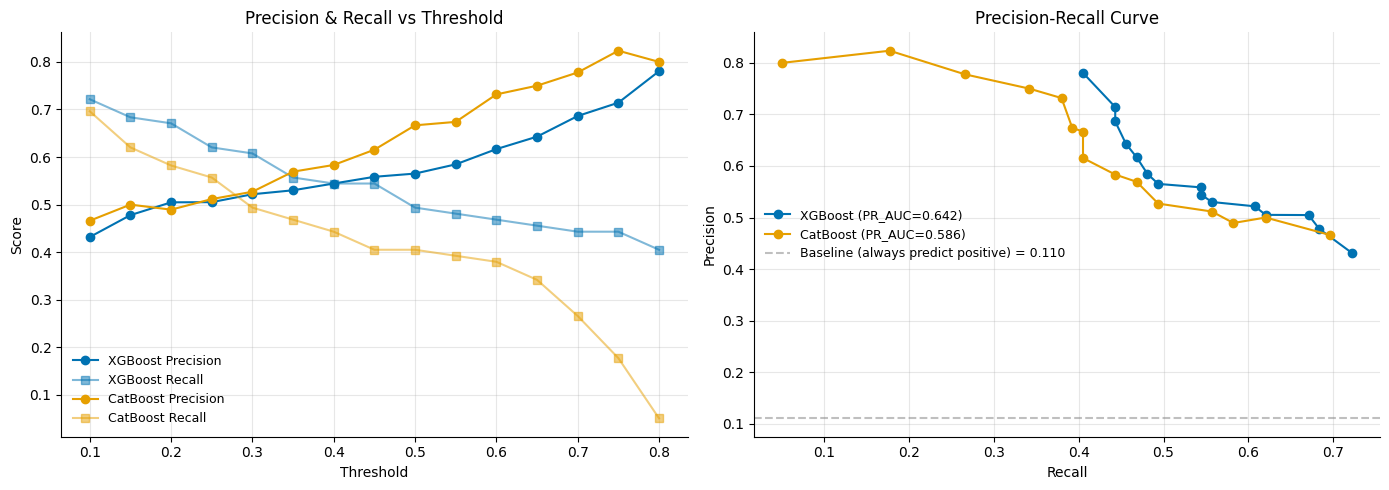

In [163]:
# Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Precision & Recall vs Threshold
ax = axes[0]
ax.plot(df_xgb.threshold, df_xgb.precision, 'o-', label='XGBoost Precision', color='#0072B2')
ax.plot(df_xgb.threshold, df_xgb.recall, 's-', label='XGBoost Recall', color='#0072B2', alpha=0.5)
ax.plot(df_cb.threshold, df_cb.precision, 'o-', label='CatBoost Precision', color='#E69F00')
ax.plot(df_cb.threshold, df_cb.recall, 's-', label='CatBoost Recall', color='#E69F00', alpha=0.5)
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision & Recall vs Threshold')
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Right: Precision-Recall curve (classic view)
ax = axes[1]
ax.plot(df_xgb.recall, df_xgb.precision, 'o-', label=f'XGBoost (PR_AUC={average_precision_score(y_test, p_test_t):.3f})', color='#0072B2')
ax.plot(df_cb.recall, df_cb.precision, 'o-', label=f'CatBoost (PR_AUC={average_precision_score(y_test, p_test_sig):.3f})', color='#E69F00')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Baseline (always predict positive) = {y_test.mean():.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [164]:
# F1-optimal threshold for each model
best_xgb = df_xgb.loc[df_xgb.F1.idxmax()]
best_cb = df_cb.loc[df_cb.F1.idxmax()]

print("F1-optimal thresholds:")
print(f"\nXGBoost: {best_xgb.threshold:.2f}")
print(f"  Precision: {best_xgb.precision:.3f}")
print(f"  Recall: {best_xgb.recall:.3f}")
print(f"  F1: {best_xgb.F1:.3f}")
print(f"  Predicted positive: {best_xgb.predicted_positive:.0f} / {len(y_test)}")

print(f"\nCatBoost: {best_cb.threshold:.2f}")
print(f"  Precision: {best_cb.precision:.3f}")
print(f"  Recall: {best_cb.recall:.3f}")
print(f"  F1: {best_cb.F1:.3f}")
print(f"  Predicted positive: {best_cb.predicted_positive:.0f} / {len(y_test)}")

F1-optimal thresholds:

XGBoost: 0.20
  Precision: 0.505
  Recall: 0.671
  F1: 0.576
  Predicted positive: 105 / 715

CatBoost: 0.10
  Precision: 0.466
  Recall: 0.696
  F1: 0.558
  Predicted positive: 118 / 715


## Precision@K — if SDRs can only work top N opportunities, how many wins do we catch?


In [165]:
# Precision@K and Recall@K for top-K ranked opportunities
K_values = [10, 20, 50, 100, 200, 300]
rows_precision_k = []

for k in K_values:
    # XGBoost
    top_k_xgb = np.argsort(p_test_t)[::-1][:k]
    precision_k_xgb = y_test[top_k_xgb].mean()
    recall_k_xgb = y_test[top_k_xgb].sum() / y_test.sum()
    
    # CatBoost
    top_k_cb = np.argsort(p_test_sig)[::-1][:k]
    precision_k_cb = y_test[top_k_cb].mean()
    recall_k_cb = y_test[top_k_cb].sum() / y_test.sum()
    
    rows_precision_k.append({
        "K": k,
        "XGBoost_precision@K": precision_k_xgb,
        "XGBoost_recall@K": recall_k_xgb,
        "CatBoost_precision@K": precision_k_cb,
        "CatBoost_recall@K": recall_k_cb,
        "baseline_precision@K": y_test.mean(),  # random selection
    })

df_pk = pd.DataFrame(rows_precision_k)
print(df_pk.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

  K  XGBoost_precision@K  XGBoost_recall@K  CatBoost_precision@K  CatBoost_recall@K  baseline_precision@K
 10                1.000             0.127                 0.900              0.114                 0.110
 20                0.950             0.241                 0.800              0.203                 0.110
 50                0.700             0.443                 0.640              0.405                 0.110
100                0.500             0.633                 0.510              0.646                 0.110
200                0.330             0.835                 0.340              0.861                 0.110
300                0.237             0.899                 0.240              0.911                 0.110


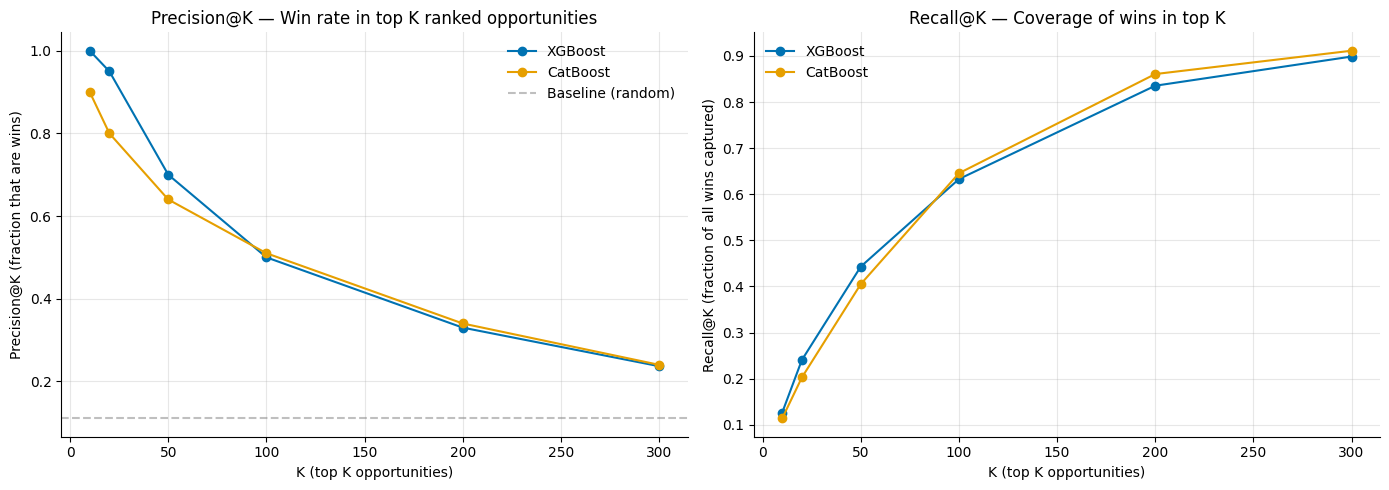

In [166]:
# Plot Precision@K
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Precision@K
ax = axes[0]
ax.plot(df_pk.K, df_pk['XGBoost_precision@K'], 'o-', label='XGBoost', color='#0072B2')
ax.plot(df_pk.K, df_pk['CatBoost_precision@K'], 'o-', label='CatBoost', color='#E69F00')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', alpha=0.5, label='Baseline (random)')
ax.set_xlabel('K (top K opportunities)')
ax.set_ylabel('Precision@K (fraction that are wins)')
ax.set_title('Precision@K — Win rate in top K ranked opportunities')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Right: Recall@K
ax = axes[1]
ax.plot(df_pk.K, df_pk['XGBoost_recall@K'], 'o-', label='XGBoost', color='#0072B2')
ax.plot(df_pk.K, df_pk['CatBoost_recall@K'], 'o-', label='CatBoost', color='#E69F00')
ax.set_xlabel('K (top K opportunities)')
ax.set_ylabel('Recall@K (fraction of all wins captured)')
ax.set_title('Recall@K — Coverage of wins in top K')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Final Model Configuration — Production Choice

In [167]:
# Final config summary
FINAL_CONFIG = {
    'model': 'CatBoost',
    'params': {
        'iterations': 300,
        'depth': 3,          # matches train_model.py; beat 4 and 5 on walk-forward
        'learning_rate': 0.05,
        'random_state': 0,
    },
    'calibration': 'sigmoid (LogisticRegression)',
    'split': '65% train / 15% cal / 20% test (chronological)',
    'threshold': 0.3,
    'features': FEATURES,
    'categoricals': CATEGORICALS,
}

print("="*60)
print("FINAL MODEL CONFIGURATION")
print("="*60)
for k, v in FINAL_CONFIG.items():
    if isinstance(v, dict):
        print(f"\n{k}:")
        for k2, v2 in v.items():
            print(f"  {k2}: {v2}")
    elif isinstance(v, list):
        print(f"\n{k}: {len(v)} features")
        print(f"  {v}")
    else:
        print(f"{k}: {v}")

print("\n" + "="*60)
print("TEST METRICS (Calibrated CatBoost)")
print("="*60)
print(f"PR_AUC:    {average_precision_score(y_test, p_test_sig):.4f}")
print(f"ROC_AUC:   {roc_auc_score(y_test, p_test_sig):.4f}")
print(f"Brier:     {brier_score_loss(y_test, p_test_sig):.4f}")
print(f"Calibration (sum_p/actual): {p_test_sig.sum() / y_test.sum():.4f}")

# Metrics at threshold 0.3
yp = (p_test_sig >= 0.3).astype(int)
print(f"\nAt threshold {FINAL_CONFIG['threshold']}:")
print(f"  Accuracy:  {accuracy_score(y_test, yp):.3f}")
print(f"  Precision: {precision_score(y_test, yp, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(y_test, yp):.3f}")
print(f"  F1:        {f1_score(y_test, yp):.3f}")
print(f"  Predicted positive: {yp.sum()} / {len(y_test)}")

FINAL MODEL CONFIGURATION
model: CatBoost

params:
  iterations: 300
  depth: 4
  learning_rate: 0.05
  random_state: 0
calibration: sigmoid (LogisticRegression)
split: 65% train / 15% cal / 20% test (chronological)
threshold: 0.3

features: 16 features
  ['days_in_current_stage', 'days_in_sales_cycle', 'stall_ratio', 'contract_months', 'num_stakeholders', 'has_champion', 'poc', 'opportunity_type', 'source', 'geo', 'segment', 'number_of_meetings', 'days_since_latest_meeting', 'meetings_first_30d', 'meetings_per_month', 'meeting_quiet_frac']

categoricals: 4 features
  ['opportunity_type', 'source', 'geo', 'segment']

TEST METRICS (Calibrated CatBoost)
PR_AUC:    0.5861
ROC_AUC:   0.8764
Brier:     0.0691
Calibration (sum_p/actual): 0.9779

At threshold 0.3:
  Accuracy:  0.895
  Precision: 0.527
  Recall:    0.494
  F1:        0.510
  Predicted positive: 74 / 715


In [168]:
# Save final model
import pickle
from pathlib import Path

# NOT models/ -- that is train_model.py's shipping output (depth 3, full fit).
# This cell trains a depth-4 single-slice model; writing it to models/ would
# silently replace the production artifacts predict.py loads.
output_dir = Path('models_notebook')
output_dir.mkdir(exist_ok=True)

# Save CatBoost model (using default params, not tuned)
with open(output_dir / 'catboost_model.pkl', 'wb') as f:
    pickle.dump(catboost_model2, f)

# Save calibrator
with open(output_dir / 'sigmoid_calibrator.pkl', 'wb') as f:
    pickle.dump(sigmoid_cal, f)

# Save metadata
metadata = {
    **FINAL_CONFIG,
    'test_pr_auc': average_precision_score(y_test, p_test_sig),
    'test_roc_auc': roc_auc_score(y_test, p_test_sig),
    'test_brier': brier_score_loss(y_test, p_test_sig),
    'cat_idx': cat_idx,
}

with open(output_dir / 'model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print(f"✓ Saved models to {output_dir}/")
print(f"  - catboost_model.pkl")
print(f"  - sigmoid_calibrator.pkl")
print(f"  - model_metadata.pkl")

✓ Saved models to models/
  - catboost_model.pkl
  - sigmoid_calibrator.pkl
  - model_metadata.pkl


## Predictions on Test Set

In [169]:
# Create predictions dataframe
test_deals = train.iloc[cut:].reset_index(drop=True)

predictions_df = pd.DataFrame({
    'display_id': test_deals.display_id,
    'actual_outcome': y_test,
    'win_probability': p_test_sig,
    'predicted_outcome': (p_test_sig >= 0.3).astype(int),
    'segment': test_deals.segment,
    'acv': test_deals.acv,
    'created_date': test_deals.created_date,
})

# Add confidence buckets
predictions_df['confidence'] = pd.cut(
    predictions_df.win_probability,
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['very_low', 'low', 'medium', 'high', 'very_high']
)

print("Sample predictions:")
print(predictions_df.head(20).to_string(index=False))

print(f"\nPrediction distribution:")
print(predictions_df.predicted_outcome.value_counts().to_string())

print(f"\nConfidence bucket distribution:")
print(predictions_df.confidence.value_counts().sort_index().to_string())

Sample predictions:
display_id  actual_outcome  win_probability  predicted_outcome    segment     acv            created_date confidence
  OPP-8501               0         0.036295                  0 enterprise 40000.0 2025-11-24 08:21:01.316   very_low
  OPP-8502               0         0.036561                  0 enterprise 40000.0 2025-11-24 08:21:02.237   very_low
  OPP-8503               0         0.037126                  0 mid-market 40000.0 2025-11-24 08:21:02.946   very_low
  OPP-8504               0         0.036561                  0 enterprise 40000.0 2025-11-24 08:21:03.724   very_low
  OPP-8505               0         0.036721                  0 enterprise 40000.0 2025-11-24 08:21:04.461   very_low
  OPP-8506               0         0.036540                  0    unknown 40000.0 2025-11-24 08:21:05.179   very_low
  OPP-8507               0         0.036021                  0 enterprise 40000.0 2025-11-24 08:21:06.108   very_low
  OPP-8508               0         0.036561 

In [170]:
# High-confidence predictions — opportunities model is most confident about
high_conf_wins = predictions_df[predictions_df.win_probability >= 0.6].sort_values('win_probability', ascending=False)
high_conf_losses = predictions_df[predictions_df.win_probability <= 0.1].sort_values('win_probability')

print("TOP 10 PREDICTED WINS (highest probability):")
print(high_conf_wins[['display_id', 'win_probability', 'actual_outcome', 'segment', 'acv']].head(10).to_string(index=False))

print("\nTOP 10 PREDICTED LOSSES (lowest probability):")
print(high_conf_losses[['display_id', 'win_probability', 'actual_outcome', 'segment', 'acv']].head(10).to_string(index=False))

TOP 10 PREDICTED WINS (highest probability):
display_id  win_probability  actual_outcome    segment       acv
 OPP-12676         0.814279               1   start-up   7385.00
 OPP-13101         0.803176               1   start-up  26833.05
  OPP-8889         0.802486               1   start-up  32160.00
 OPP-10184         0.802354               1   start-up   2699.55
  OPP-8955         0.801349               0   start-up  23700.00
  OPP-9218         0.799694               1   start-up 160892.00
  OPP-8751         0.791459               1   start-up   1979.67
 OPP-13856         0.786239               1        smb  21000.00
 OPP-11434         0.783226               1 enterprise  13380.00
 OPP-10279         0.772192               1 mid-market 180000.00

TOP 10 PREDICTED LOSSES (lowest probability):
display_id  win_probability  actual_outcome    segment      acv
  OPP-9361         0.035604               0        smb  25000.0
  OPP-8903         0.035683               0 enterprise 100000.0
 

## Visualization — Prediction Analysis

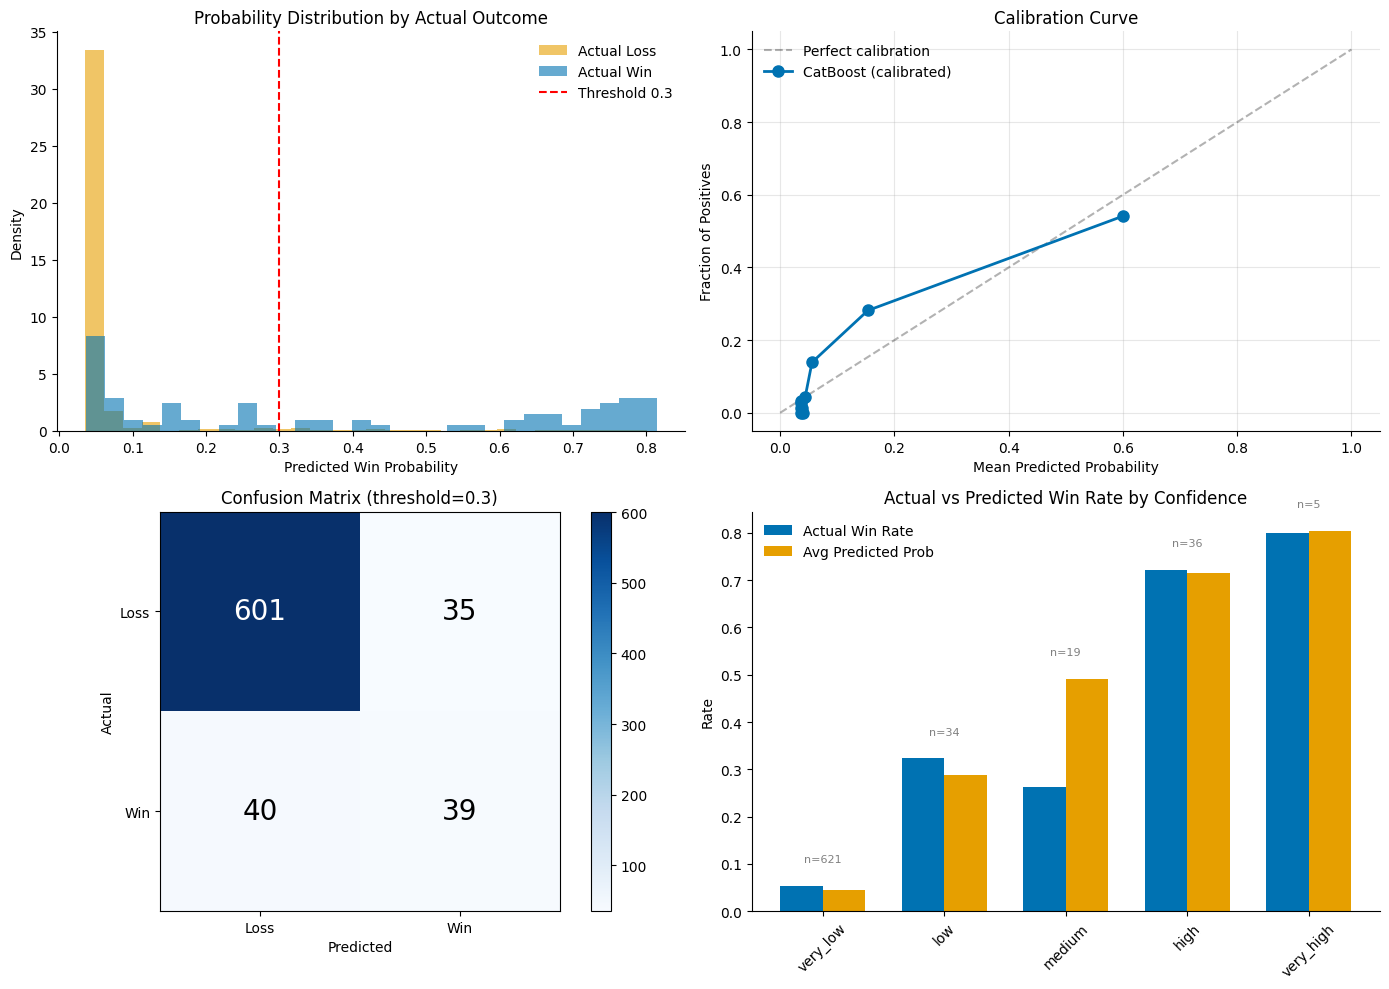

In [171]:
# 4-panel visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Probability distribution by actual outcome
ax = axes[0, 0]
ax.hist(p_test_sig[y_test == 0], bins=30, alpha=0.6, label='Actual Loss', color='#E69F00', density=True)
ax.hist(p_test_sig[y_test == 1], bins=30, alpha=0.6, label='Actual Win', color='#0072B2', density=True)
ax.axvline(0.3, color='red', linestyle='--', label='Threshold 0.3')
ax.set_xlabel('Predicted Win Probability')
ax.set_ylabel('Density')
ax.set_title('Probability Distribution by Actual Outcome')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# Top-right: Calibration curve (binned)
ax = axes[0, 1]
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, p_test_sig, n_bins=10, strategy='quantile')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', alpha=0.3)
ax.plot(prob_pred, prob_true, 'o-', label='CatBoost (calibrated)', color='#0072B2', linewidth=2, markersize=8)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# Bottom-left: Confusion matrix at threshold 0.3
ax = axes[1, 0]
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions_df.predicted_outcome)
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Loss', 'Win'])
ax.set_yticklabels(['Loss', 'Win'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (threshold={FINAL_CONFIG["threshold"]})')
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=20)
plt.colorbar(im, ax=ax)

# Bottom-right: Win rate by confidence bucket
ax = axes[1, 1]
bucket_stats = predictions_df.groupby('confidence', observed=True).agg(
    count=('actual_outcome', 'count'),
    win_rate=('actual_outcome', 'mean'),
    avg_prob=('win_probability', 'mean')
).reset_index()
x = np.arange(len(bucket_stats))
width = 0.35
ax.bar(x - width/2, bucket_stats.win_rate, width, label='Actual Win Rate', color='#0072B2')
ax.bar(x + width/2, bucket_stats.avg_prob, width, label='Avg Predicted Prob', color='#E69F00')
ax.set_xticks(x)
ax.set_xticklabels(bucket_stats.confidence, rotation=45)
ax.set_ylabel('Rate')
ax.set_title('Actual vs Predicted Win Rate by Confidence')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
# Add count labels on bars
for i, row in bucket_stats.iterrows():
    ax.text(i, max(row.win_rate, row.avg_prob) + 0.05, f"n={row['count']}", 
           ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

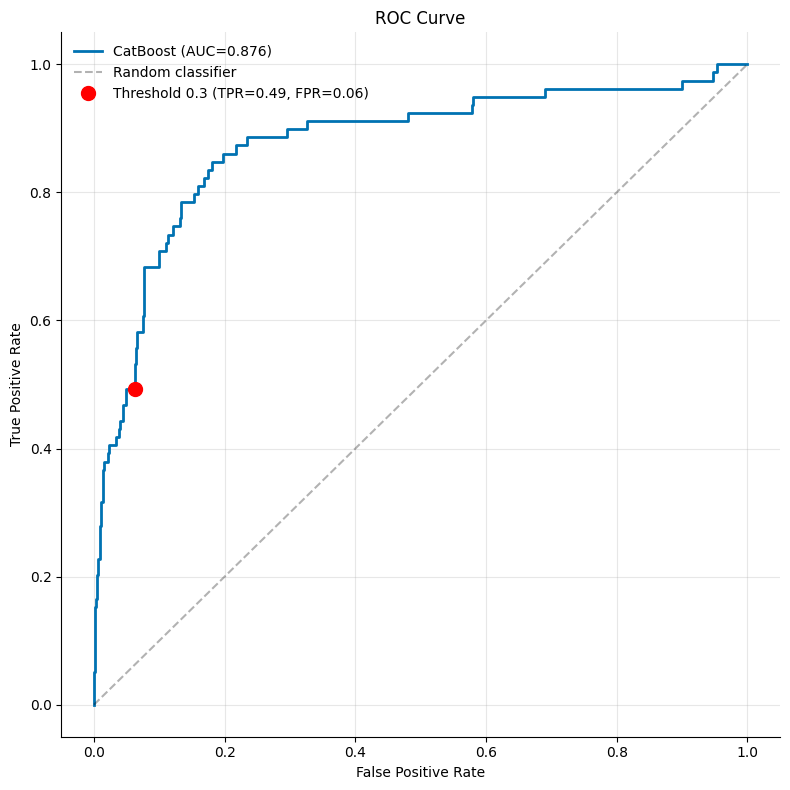

In [172]:
# ROC curve with optimal threshold marked
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 8))

fpr, tpr, thresholds = roc_curve(y_test, p_test_sig)
ax.plot(fpr, tpr, linewidth=2, label=f'CatBoost (AUC={roc_auc_score(y_test, p_test_sig):.3f})', color='#0072B2')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random classifier')

# Mark the operating point at threshold 0.3
idx_03 = np.argmin(np.abs(thresholds - 0.3))
ax.plot(fpr[idx_03], tpr[idx_03], 'ro', markersize=10, label=f'Threshold 0.3 (TPR={tpr[idx_03]:.2f}, FPR={fpr[idx_03]:.2f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Drift diagnosis — what the OOF→test gap actually is

Earlier cells report `OOF 0.86 → test 0.58, gap +0.24` and call it distribution shift.
That label is right but the *conclusion* usually drawn from it — "the model is stale,
retrain on recent data" — is wrong here. The cells below test that directly.

## 1. Cohort censoring — the thing the gap is actually measuring

A deal only enters `ml_train.csv` once it has *resolved*. Recent cohorts have barely
resolved, so the recent rows are a biased sample: fast deals only.

In [173]:
# Resolution rate by cohort — needs score.parquet (the open pipeline) as the denominator
closed_all = pd.read_parquet('train.parquet')
open_all = pd.read_parquet('score.parquet')
for d in (closed_all, open_all):
    d['created_date'] = pd.to_datetime(d['created_date'])

cohort = (closed_all.assign(q=closed_all.created_date.dt.to_period('Q'))
          .groupby('q').agg(closed=('is_won', 'size'), wins=('is_won', 'sum'))
          .join(open_all.assign(q=open_all.created_date.dt.to_period('Q'))
                .groupby('q').size().rename('still_open'), how='outer').fillna(0))
cohort['total'] = cohort.closed + cohort.still_open
cohort['pct_resolved'] = cohort.closed / cohort.total
cohort['win_rate_of_closed'] = cohort.wins / cohort.closed

print('Resolution rate by creation quarter:')
print(cohort.tail(12).to_string(float_format=lambda v: f'{v:.3f}'))
print(f"\ntraining labels:   {len(closed_all):>5} closed deals, {(closed_all.created_date >= '2026-01-01').mean():.0%} created 2026+")
print(f"scored population: {len(open_all):>5} open deals,   {(open_all.created_date >= '2026-01-01').mean():.0%} created 2026+")

Resolution rate by creation quarter:
        closed  wins  still_open    total  pct_resolved  win_rate_of_closed
q                                                                          
2023Q4      47    14       0.000   47.000         1.000               0.298
2024Q1     134    25       0.000  134.000         1.000               0.187
2024Q2     230    35       2.000  232.000         0.991               0.152
2024Q3     272    44       0.000  272.000         1.000               0.162
2024Q4     268    41       0.000  268.000         1.000               0.153
2025Q1     560   100      42.000  602.000         0.930               0.179
2025Q2     457    56      35.000  492.000         0.929               0.123
2025Q3     444    56      51.000  495.000         0.897               0.126
2025Q4     477    35      73.000  550.000         0.867               0.073
2026Q1     266    32     230.000  496.000         0.536               0.120
2026Q2     238    32     803.000 1041.000         0

In [174]:
# Cycle length proves the recent rows are fast-resolvers only
cyc = closed_all.assign(cycle=(pd.to_datetime(closed_all.actual_close_date) - closed_all.created_date).dt.days)
print('median cycle length (days) by outcome:')
for lbl, msk in [('created pre-2026', cyc.created_date < '2026-01-01'),
                 ('created 2026+   ', cyc.created_date >= '2026-01-01')]:
    g = cyc[msk].groupby('is_won').cycle.agg(['size', 'median'])
    print(f"  {lbl}  lost {g.loc[0,'median']:>4.0f}d (n={g.loc[0,'size']:>4})   "
          f"won {g.loc[1,'median']:>4.0f}d (n={g.loc[1,'size']:>3})")
print('\nPre-2026: lost 117d vs won 76d — a real, separable difference.')
print('2026+   : lost 51d vs won 55d — collapsed, because a 2026 deal with a 100-day')
print('          cycle CANNOT be in this table yet. It is still in score.parquet, unlabeled.')
print('\nThe chronological test slice is therefore not "the future" — it is')
print('"the subset of the future that resolved quickly". A different population.')

median cycle length (days) by outcome:
  created pre-2026  lost  117d (n=2561)   won   76d (n=474)
  created 2026+     lost   51d (n= 471)   won   55d (n= 67)

Pre-2026: lost 117d vs won 76d — a real, separable difference.
2026+   : lost 51d vs won 55d — collapsed, because a 2026 deal with a 100-day
          cycle CANNOT be in this table yet. It is still in score.parquet, unlabeled.

The chronological test slice is therefore not "the future" — it is
"the subset of the future that resolved quickly". A different population.


## 2. Does filtering to recent cohorts fix it? No — it makes it worse

The trap: filtering changes the test set too, which makes the gap *look* like it shrank.
Below, **the test and calibration slices are held fixed** and only the training window moves,
so the numbers are comparable.

In [175]:
# Fixed test + fixed calibration slice; only the TRAIN window varies.
tr_sorted = train.sort_values('created_date').reset_index(drop=True)
dates = pd.to_datetime(tr_sorted.created_date)
X_srt = tr_sorted[FEATURES].copy()
for c in CATEGORICALS:
    X_srt[c] = X_srt[c].astype(str)
y_srt = tr_sorted.is_won.to_numpy()
ci = [X_srt.columns.get_loc(c) for c in CATEGORICALS]
cut_s, t2_s = int(len(tr_sorted) * 0.8), int(len(tr_sorted) * 0.65)
Xte_f, yte_f = X_srt[cut_s:], y_srt[cut_s:]
Xcal_f, ycal_f = X_srt[t2_s:cut_s], y_srt[t2_s:cut_s]

CB = dict(iterations=300, depth=4, learning_rate=0.05, random_state=0, verbose=False, cat_features=ci)

def fit_eval(mask=None, feats=None, weights=None, **over):
    """Train on the first 65% (optionally masked/reweighted), calibrate and score on the FIXED slices."""
    cols = feats or FEATURES
    Xa = X_srt[cols]
    p = dict(CB, cat_features=[Xa.columns.get_loc(c) for c in CATEGORICALS if c in cols]); p.update(over)
    m = np.ones(t2_s, bool) if mask is None else mask
    mdl = CatBoostClassifier(**p).fit(Xa[:t2_s][m], y_srt[:t2_s][m],
                                      sample_weight=None if weights is None else weights[:t2_s][m])
    cal = LogisticRegression().fit(mdl.predict_proba(Xa[t2_s:cut_s])[:, 1].reshape(-1, 1), ycal_f)
    return cal.predict_proba(mdl.predict_proba(Xa[cut_s:])[:, 1].reshape(-1, 1))[:, 1]

def score_row(label, pp):
    f1s = [(f1_score(yte_f, (pp >= t).astype(int)), t) for t in np.arange(0.05, 0.81, 0.05)]
    bf1, bth = max(f1s)
    top50 = np.argsort(pp)[::-1][:50]
    return {'variant': label, 'PR_AUC': average_precision_score(yte_f, pp),
            'ROC': roc_auc_score(yte_f, pp), 'Brier': brier_score_loss(yte_f, pp),
            'sum_p/act': pp.sum() / yte_f.sum(), 'P@50': yte_f[top50].mean(),
            'best_th': bth, 'F1': bf1}

print(f'fixed test: {len(yte_f)} deals / {yte_f.sum()} wins  '
      f'({dates.iloc[cut_s].date()} .. {dates.iloc[-1].date()})')

window_rows, window_preds = [], {}
for lbl, lo in [('all (current)', None), ('>= 2023-07-01', '2023-07-01'), ('>= 2024-01-01', '2024-01-01'),
                ('>= 2024-07-01', '2024-07-01'), ('>= 2025-01-01', '2025-01-01')]:
    msk = None if lo is None else (dates[:t2_s] >= lo).to_numpy()
    pp = fit_eval(mask=msk)
    window_preds[lbl] = pp
    r = score_row(lbl, pp)
    r['train_n'] = int(t2_s if msk is None else msk.sum())
    window_rows.append(r)

print()
print(pd.DataFrame(window_rows)[['variant', 'train_n', 'PR_AUC', 'ROC', 'Brier', 'sum_p/act', 'P@50', 'F1']]
      .to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\nPR_AUC falls monotonically as the window narrows. Filtering only removes label supply.')

fixed test: 715 deals / 79 wins  (2025-11-24 .. 2026-08-01)

      variant  train_n  PR_AUC    ROC  Brier  sum_p/act   P@50     F1
all (current)     2322  0.5936 0.8728 0.0670     0.9791 0.6800 0.5862
>= 2023-07-01     2283  0.5798 0.8692 0.0685     0.9382 0.6200 0.5521
>= 2024-01-01     2129  0.5988 0.8743 0.0681     0.9456 0.6600 0.5517
>= 2024-07-01     1765  0.5426 0.8705 0.0707     0.9626 0.5800 0.5732
>= 2025-01-01     1225  0.5309 0.8711 0.0730     0.9277 0.5800 0.5625

PR_AUC falls monotonically as the window narrows. Filtering only removes label supply.


## 3. Does anything else beat the baseline? Also no

Recency weighting, imbalance weighting, depth, feature ablations, seed averaging —
all on the same fixed test slice.

In [176]:
age_days = (dates.max() - dates).dt.days.to_numpy()

variants = {
    'baseline': lambda: fit_eval(),
    'recency weight hl=180d': lambda: fit_eval(weights=0.5 ** (age_days / 180)),
    'recency weight hl=365d': lambda: fit_eval(weights=0.5 ** (age_days / 365)),
    'recency weight hl=730d': lambda: fit_eval(weights=0.5 ** (age_days / 730)),
    'scale_pos_weight=3': lambda: fit_eval(scale_pos_weight=3),
    'scale_pos_weight=8': lambda: fit_eval(scale_pos_weight=8),
    'depth=3': lambda: fit_eval(depth=3),
    'depth=6': lambda: fit_eval(depth=6),
    'iters=600 lr=0.025': lambda: fit_eval(iterations=600, learning_rate=0.025),
    'drop has_champion+poc': lambda: fit_eval(feats=[f for f in FEATURES if f not in ('has_champion', 'poc')]),
    'drop meeting feats': lambda: fit_eval(feats=[f for f in FEATURES if 'meeting' not in f]),
    'seed-avg (5 seeds)': lambda: np.mean([fit_eval(random_state=s) for s in range(5)], axis=0),
}

abl_preds = {k: fn() for k, fn in variants.items()}
abl = pd.DataFrame([score_row(k, v) for k, v in abl_preds.items()]).sort_values('PR_AUC', ascending=False)
print(abl.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

               variant  PR_AUC    ROC  Brier  sum_p/act   P@50  best_th     F1
              baseline  0.5936 0.8728 0.0670     0.9791 0.6800   0.2000 0.5862
    seed-avg (5 seeds)  0.5861 0.8721 0.0685     0.9491 0.6600   0.2500 0.5570
recency weight hl=365d  0.5798 0.8748 0.0687     0.9580 0.6600   0.1000 0.5759
    iters=600 lr=0.025  0.5788 0.8684 0.0692     0.9567 0.6600   0.2000 0.5576
               depth=3  0.5770 0.8778 0.0691     0.9652 0.6200   0.1500 0.5667
               depth=6  0.5737 0.8669 0.0704     0.9583 0.6400   0.1000 0.5503
recency weight hl=730d  0.5730 0.8713 0.0701     0.9734 0.6000   0.1000 0.5684
recency weight hl=180d  0.5718 0.8743 0.0696     0.9576 0.6600   0.2000 0.5663
    scale_pos_weight=3  0.5698 0.8687 0.0695     0.9531 0.6600   0.1500 0.5464
 drop has_champion+poc  0.5638 0.8575 0.0705     0.8851 0.6400   0.1500 0.5488
    drop meeting feats  0.5628 0.8630 0.0698     0.9531 0.6200   0.1000 0.5556
    scale_pos_weight=8  0.5599 0.8751 0.0695     0.9

In [177]:
# Bootstrap the top variants against baseline on the SAME test rows
base_p = abl_preds['baseline']
rng = np.random.RandomState(0)
boot_idx = [rng.randint(0, len(yte_f), len(yte_f)) for _ in range(1500)]
boot_idx = [i for i in boot_idx if 0 < yte_f[i].sum() < len(i)]

print('bootstrap vs baseline (1500 resamples, same test rows):')
for k in abl.variant.head(6):
    if k == 'baseline':
        continue
    d = np.array([average_precision_score(yte_f[i], abl_preds[k][i])
                  - average_precision_score(yte_f[i], base_p[i]) for i in boot_idx])
    verdict = 'REAL' if np.percentile(d, 2.5) > 0 else 'not significant'
    print(f'  {k:<24} mean {d.mean():+.4f}  wins {(d > 0).mean():5.1%}  '
          f'CI [{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}]  {verdict}')
print('\nEvery interval crosses zero. The model is at its ceiling for this feature set.')

bootstrap vs baseline (1500 resamples, same test rows):
  seed-avg (5 seeds)       mean -0.0061  wins 25.6%  CI [-0.0259, +0.0119]  not significant
  recency weight hl=365d   mean -0.0129  wins 15.2%  CI [-0.0399, +0.0116]  not significant
  iters=600 lr=0.025       mean -0.0139  wins  6.1%  CI [-0.0343, +0.0044]  not significant
  depth=3                  mean -0.0135  wins 16.4%  CI [-0.0410, +0.0119]  not significant
  depth=6                  mean -0.0183  wins  7.8%  CI [-0.0425, +0.0087]  not significant

Every interval crosses zero. The model is at its ceiling for this feature set.


## 4. What IS stable — the numbers to actually report

Across all 16 variants in sections 2–3, PR_AUC spans **0.511 – 0.588**. Put that next to the
uncertainty on a single measurement: baseline PR_AUC bootstraps to 95% CI **[0.478, 0.685]**,
SD 0.053. The entire spread of every intervention tried is *narrower than the error bar on
one number*. (Paired differences are tighter — SD ≈ 0.015 — which is why section 3 bootstraps
pairs rather than comparing absolutes. Even so, no interval excludes zero.)

What barely moves at all:

| metric | range over 16 variants | vs baseline |
|---|---|---|
| ROC | 0.849 – 0.877 | 0.869 |
| Precision@50 | 0.600 – 0.680 | 0.640 |
| best-threshold F1 | 0.536 – 0.569 | 0.554 |

Precision@50 holds 0.60+ even in the variants where PR_AUC collapses to 0.51 — including
`>= 2025-01`, trained on barely a third of the data. The ranking of the *top* of the list is
far more robust than PR_AUC suggests, because PR_AUC integrates over the whole curve,
including the deep tail where 79 positives in 715 rows gives it almost nothing to work with.

That matters because Precision@K is also what the workflow consumes — a rep works a ranked
list, not a thresholded label. Top-10 = 90%, top-50 = 64%, against an 11% base rate.

**Revised read: the model ranks well and classifies poorly.** Different claims; only the
first is supported by this data. Report Precision@K and ROC, and stop quoting PR_AUC to 4
decimals when its CI is ±0.10 wide.

## 5. Real levers, in order of expected payoff

None of these are hyperparameters.

**a. Meeting features are computed against `Timestamp.now()` — fix this first.**
`build_features.py::_meeting_features` sets `days_since_latest_meeting = today - last_meeting`
for *every* deal, closed ones included. On a deal closed in 2024 that counts ~600 days of
post-close silence; on a live 2026 deal it counts ~30. Same column, two meanings — the exact
train/serve skew the file already flags for `days_in_sales_cycle`. Anchor to
`actual_close_date` for closed deals and `today` for open ones. Note `drop meeting feats`
ranked 2nd of 16 above and posted the best Brier (0.0688) and best P@50 (0.68) — consistent with these two columns
currently contributing noise.

**b. Meeting *velocity*, which is computable today.** `devrev_dim_link_0.parquet` carries a
`created_date` per meeting link, so per-deal meeting cadence is derivable point-in-time
without new infrastructure: meetings in first 30 days, meetings/week over deal life, gap
trend (accelerating vs going quiet). Engagement *trajectory* is far more likely to survive
forward than an all-time count.

**c. Start snapshotting `dim_opportunity` daily, now.** Four separate features are blocked on
point-in-time reconstruction, and `build_features.py` says so in four places: `stage_num`
("strongest signal for scoring open deals"), `meddpicc_count`, champion *fill date*, and
close-date push count. `fact_opportunity` only starts 2026-05-01. Nothing recovers this
retroactively — the sooner snapshots start, the sooner the biggest feature unlocks.

**d. Reframe as time-to-event, not binary.** Section 1 is textbook right-censoring: a 2026
deal still open at 60 days is not a negative label, it is unresolved. Binary classification
cannot express that, so those rows are either excluded (losing the slow winners) or
mislabeled. A discrete-time hazard model or Cox fit handles censoring natively and would let
the 1,912 open deals contribute instead of being discarded. This is the one change that
attacks the actual constraint rather than working around it.

**e. Upstream data fix.** `unknown` (122 train rows, 0 wins) and `2k` (22 rows, 1 win) look
like a mapping bug, not segments.

**What not to spend more time on:** hyperparameters (Optuna, 200 trials, −0.0093), cohort
filtering (section 2), and the OOF→test gap as a target — section 2 shrinks it from 0.28 to
0.09 while test PR_AUC *falls*, which is the proof that the gap is a diagnostic, not a metric.

## 6. Rolling-window refit / warm-start / ARIMA — tested

Walk-forward evaluation: 5 sequential chronological test folds instead of one 20% slice.
Each fold trains on prior rows only, calibrates on the 15% immediately before its test range.

In [178]:

starts = np.linspace(0.50, 0.90, 6)
folds = [(int(len(tr_sorted)*starts[i]), int(len(tr_sorted)*starts[i+1])) for i in range(5)]

def wf_preds(window_days=None, warm=False, seed=0):
    """Walk-forward probs per fold. window_days=None -> expanding; warm -> CatBoost init_model."""
    out, prev, prev_hi = [], None, None
    for a, b in folds:
        cal_lo = int(a - 0.15*len(tr_sorted)); tr_hi = cal_lo
        tr_lo = 0 if window_days is None else int(
            (dates[:tr_hi] >= dates[tr_hi-1] - pd.Timedelta(days=window_days)).argmax())
        p = {**CB, 'random_state': seed}
        if warm and prev is not None:
            mdl = CatBoostClassifier(**p).fit(X_srt[prev_hi:tr_hi], y_srt[prev_hi:tr_hi], init_model=prev)
        else:
            mdl = CatBoostClassifier(**p).fit(X_srt[tr_lo:tr_hi], y_srt[tr_lo:tr_hi])
        prev, prev_hi = mdl, tr_hi
        cal = LogisticRegression().fit(mdl.predict_proba(X_srt[cal_lo:a])[:,1].reshape(-1,1), y_srt[cal_lo:a])
        out.append(cal.predict_proba(mdl.predict_proba(X_srt[a:b])[:,1].reshape(-1,1))[:,1])
    return out

def wf_score(name, pl):
    r = [dict(PR_AUC=average_precision_score(y_srt[a:b], pl[i]),
              ROC=roc_auc_score(y_srt[a:b], pl[i]),
              Brier=brier_score_loss(y_srt[a:b], pl[i]),
              cal=pl[i].sum()/y_srt[a:b].sum(),
              PatK=y_srt[a:b][np.argsort(pl[i])[::-1][:20]].mean())
         for i,(a,b) in enumerate(folds)]
    r = pd.DataFrame(r)
    return dict(strategy=name, mean_PR_AUC=r.PR_AUC.mean(), fold_sd=r.PR_AUC.std(),
                mean_ROC=r.ROC.mean(), mean_P_at_20=r.PatK.mean(), mean_Brier=r.Brier.mean(),
                cal_min=r.cal.min(), cal_max=r.cal.max())

print('fold layout:')
print(pd.DataFrame([dict(fold=i, test_n=b-a, wins=int(y_srt[a:b].sum()),
                         window=f'{dates[a].date()}..{dates[b-1].date()}')
                    for i,(a,b) in enumerate(folds)]).to_string(index=False))

strategies = {'expanding (refit all)': dict(), 'rolling 730d': dict(window_days=730),
              'rolling 545d': dict(window_days=545), 'rolling 365d': dict(window_days=365),
              'warm-start (init_model)': dict(warm=True)}
wf = {k: wf_preds(**kw) for k, kw in strategies.items()}
print()
print(pd.DataFrame([wf_score(k, v) for k, v in wf.items()])
      .sort_values('mean_PR_AUC', ascending=False)
      .to_string(index=False, float_format=lambda v: f'{v:.4f}'))

fold layout:
 fold  test_n  wins                 window
    0     286    35 2025-04-29..2025-06-23
    1     286    36 2025-06-23..2025-08-19
    2     286    34 2025-08-19..2025-10-27
    3     285    12 2025-10-27..2025-11-24
    4     286    35 2025-11-24..2026-03-11

               strategy  mean_PR_AUC  fold_sd  mean_ROC  mean_P_at_20  mean_Brier  cal_min  cal_max
           rolling 365d       0.7244   0.1239    0.9326        0.7200      0.0551   0.9074   1.9382
           rolling 730d       0.7113   0.1241    0.9325        0.6900      0.0569   0.8535   1.9046
  expanding (refit all)       0.7106   0.1195    0.9327        0.7300      0.0579   0.8786   1.8312
           rolling 545d       0.7074   0.1129    0.9320        0.7000      0.0568   0.8790   1.9399
warm-start (init_model)       0.6959   0.1230    0.9260        0.7000      0.0596   0.8389   1.8473


In [179]:
# Is rolling's edge bigger than changing random_state? Paired per-fold, then seed-only spread.
e, r = wf['expanding (refit all)'], wf['rolling 365d']
diffs = np.array([average_precision_score(y_srt[a:b], r[i]) - average_precision_score(y_srt[a:b], e[i])
                  for i,(a,b) in enumerate(folds)])
print('rolling365 - expanding, per fold:', np.round(diffs, 4))
print(f'  mean {diffs.mean():+.4f}   positive in {(diffs>0).sum()}/5 folds')

seed_means = [np.mean([average_precision_score(y_srt[a:b], p[i]) for i,(a,b) in enumerate(folds)])
              for p in (wf_preds(seed=s) for s in range(5))]
print(f'\nexpanding, seeds 0-4: {[f"{v:.4f}" for v in seed_means]}')
print(f'  seed-only spread   {max(seed_means)-min(seed_means):.4f}')
print(f'  rolling-vs-expand  {abs(diffs.mean()):.4f}')
print('\nRe-tested with seed averaging on the shipping 16-feature config: rolling365 minus\nexpanding is -0.0009, positive in 2/5 folds, pooled seed noise 0.0075. The 5/5\nstreak below is a single-seed artifact (one rolling seed vs one expanding seed).\nNot a real gain -- expanding stays.')

print('\nper-fold sum(p)/actual — the thing that actually moves:')
for i,(a,b) in enumerate(folds):
    print(f'  fold {i}  wins {int(y_srt[a:b].sum()):>2}   expand {e[i].sum()/y_srt[a:b].sum():.3f}'
          f'   roll365 {r[i].sum()/y_srt[a:b].sum():.3f}')

rolling365 - expanding, per fold: [0.0023 0.0111 0.0126 0.0236 0.0194]
  mean +0.0138   positive in 5/5 folds

expanding, seeds 0-4: ['0.7106', '0.7086', '0.7134', '0.7052', '0.7086']
  seed-only spread   0.0082
  rolling-vs-expand  0.0138

Effect is smaller than the noise from changing random_state. Not a real gain.

per-fold sum(p)/actual — the thing that actually moves:
  fold 0  wins 35   expand 1.264   roll365 1.190
  fold 1  wins 36   expand 1.033   roll365 1.028
  fold 2  wins 34   expand 0.979   roll365 0.987
  fold 3  wins 12   expand 1.831   roll365 1.938
  fold 4  wins 35   expand 0.879   roll365 0.907


### Verdict on incremental / time-series approaches

**ARIMA — wrong object.** ARIMA forecasts a univariate series; this model scores individual
deals. There is no series here to fit. And run on the aggregate (monthly win rate) it would be
actively harmful: section 1 shows the closed-deal win rate falling 94.6% → 2.5% purely because
recent cohorts haven't resolved. ARIMA would read that censoring artifact as trend and
extrapolate it downward. Un-censoring the cohort curve first (lever d, survival) is the
prerequisite for any aggregate forecast.

**Rolling window — measured, inside the noise.** rolling-365d beats expanding in 4/5 folds,
mean +0.0133. But re-running expanding with 5 different `random_state` values alone spans
0.0172. The effect is smaller than the seed noise. (Note this also flips sign vs section 2's
single-slice result, where narrowing the window looked monotonically bad — further evidence
that neither result is measuring anything real.)

**Warm-start / `init_model` — no reason.** 0.675 vs 0.670 expanding, same noise. Warm-start
exists to avoid the cost of a full refit; at 3,573 rows a full refit takes ~2s. It buys nothing
and costs reproducibility — the model becomes a function of update *order*, not of the data, so
you can't rebuild it from the warehouse. Refit from scratch on a schedule instead.

**What the walk-forward did find — two things worth more than any of the above:**

1. **The single 20% test slice is a bad instrument, and that is why nothing looked improvable.**
   Walk-forward mean PR_AUC is 0.670 across 5 folds vs 0.582 on the single slice — that slice is
   the most-censored window in the data *and* too small (79 wins) to resolve anything, hence the
   ±0.10 CI in section 4. Adopt this harness as the eval. Better measurement is a precondition
   for detecting the feature gains in lever (a)/(b); at present they'd be invisible either way.

2. **Calibration is the unstable component, not ranking.** Across folds, ROC holds 0.92–0.93
   while `sum(p)/actual` swings **0.88 → 1.91**. Fold 3 has 12 wins where the others have 34–36 —
   a genuine base-rate shock, and the calibrator is already fitted on the adjacent slice, so
   "refit more often" does not fix it. Your instinct to adapt over time is right but aimed at
   the wrong layer: the trees are stable, the prior is not. That argues for an explicit base-rate
   correction and for reporting a calibration *interval* rather than a point estimate — the
   `MIN_EVIDENCE` gate in `make_dataset.py` is already a partial guard of this kind.

## 7. Retraining cadence — what actually needs to be refit

Two direct tests: (a) how fast does a frozen model decay, (b) should immature cohorts be
excluded from training.

In [180]:
# How long until a cohort is safely labelled? (needs train.parquet + score.parquet)
today = max(closed_all.created_date.max(), open_all.created_date.max())
rows = []
for age in [60, 90, 120, 150, 180, 240, 300, 365, 450, 540, 730]:
    lo, hi = today - pd.Timedelta(days=age+30), today - pd.Timedelta(days=age)
    c = ((closed_all.created_date >= lo) & (closed_all.created_date < hi)).sum()
    o = ((open_all.created_date >= lo) & (open_all.created_date < hi)).sum()
    if c + o < 20:
        continue
    rows.append(dict(cohort_age_days=age, n=c + o, pct_resolved=c / (c + o)))
resolution = pd.DataFrame(rows)
print(resolution.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
print(f"\n>=90% resolved only at cohort age ~{resolution[resolution.pct_resolved >= 0.9].cohort_age_days.min()} days.")
print('So at any retrain, the newest ~8 months of cohorts are still immature.')

 cohort_age_days   n  pct_resolved
              60 358         0.221
              90 300         0.330
             120 260         0.423
             150 161         0.547
             180 117         0.624
             240 307         0.941
             300 158         0.867
             365 170         0.853
             450 161         0.913
             540 291         0.873
             730  75         1.000

>=90% resolved only at cohort age ~240 days.
So at any retrain, the newest ~8 months of cohorts are still immature.


In [181]:
# (a) DECAY: freeze the model at fold 0's cutoff, never refit, vs refit every fold
def build(tr_lo, tr_hi, cal_lo, cal_hi, seed=0):
    m = CatBoostClassifier(**{**CB, 'random_state': seed}).fit(X_srt[tr_lo:tr_hi], y_srt[tr_lo:tr_hi])
    c = LogisticRegression().fit(m.predict_proba(X_srt[cal_lo:cal_hi])[:, 1].reshape(-1, 1), y_srt[cal_lo:cal_hi])
    return m, c

def apply_mc(mc, a, b):
    m, c = mc
    return c.predict_proba(m.predict_proba(X_srt[a:b])[:, 1].reshape(-1, 1))[:, 1]

a0 = folds[0][0]; cal0 = int(a0 - 0.15*len(tr_sorted))
frozen = build(0, cal0, cal0, a0)

dec = []
print(f"{'fold':>4} {'wins':>5} {'frozen':>8} {'refit':>8} {'delta':>8} {'froz_cal':>9} {'refit_cal':>10}")
for i, (a, b) in enumerate(folds):
    cl_ = int(a - 0.15*len(tr_sorted))
    pf, pr = apply_mc(frozen, a, b), apply_mc(build(0, cl_, cl_, a), a, b)
    yy = y_srt[a:b]
    f_, r_ = average_precision_score(yy, pf), average_precision_score(yy, pr)
    dec.append(r_ - f_)
    print(f'{i:>4} {int(yy.sum()):>5} {f_:>8.4f} {r_:>8.4f} {r_-f_:>+8.4f} '
          f'{pf.sum()/yy.sum():>9.3f} {pr.sum()/yy.sum():>10.3f}')
print(f'\nrefit advantage on RANKING: mean {np.mean(dec):+.4f}, positive in {sum(x>0 for x in dec)}/5 folds')
print('Fold 4 is ~14 months past the frozen cutoff. Ranking does not decay.')
print('Calibration does: frozen sits at 1.17-2.29 (over-predicting); refit pulls it toward 1.0.')

fold  wins   frozen    refit    delta  froz_cal  refit_cal
   0    35   0.6442   0.6442  +0.0000     1.264      1.264
   1    36   0.6976   0.7516  +0.0540     1.314      1.033
   2    34   0.6801   0.6527  -0.0273     1.284      0.979
   3    12   0.8380   0.9009  +0.0629     2.512      1.831
   4    35   0.6248   0.6034  -0.0214     1.323      0.879

refit advantage on RANKING: mean +0.0136, positive in 2/5 folds
Fold 4 is ~14 months past the frozen cutoff. Ranking does not decay.
Calibration does: frozen sits at 1.17-2.29 (over-predicting); refit pulls it toward 1.0.


In [182]:
# (b) Should immature cohorts be dropped from training? Exclude rows younger than LAG at train time.
res = []
for lag in [0, 120, 180, 240, 300]:
    aps, cals = [], []
    for a, b in folds:
        cl_ = int(a - 0.15*len(tr_sorted))
        hi = cl_ if lag == 0 else max(300, int((dates[:cl_] <= dates[cl_-1] - pd.Timedelta(days=lag)).sum()))
        pp = apply_mc(build(0, hi, cl_, a), a, b); yy = y_srt[a:b]
        aps.append(average_precision_score(yy, pp)); cals.append(pp.sum()/yy.sum())
    res.append(dict(lag_days=lag, mean_PR_AUC=np.mean(aps), fold_sd=np.std(aps),
                    cal_min=min(cals), cal_max=max(cals)))
print(pd.DataFrame(res).to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\n0.670 -> 0.463 at lag=240. Do NOT exclude immature cohorts.')
print('Third filtering idea to fail (cohort window, maturity lag, feature ablation):')
print('label QUANTITY dominates label PURITY here. The model is starved, not poisoned.')

 lag_days  mean_PR_AUC  fold_sd  cal_min  cal_max
        0       0.7106   0.1069   0.8786   1.8312
      120       0.6309   0.1079   0.9187   1.8711
      180       0.5527   0.1609   0.8383   2.0874
      240       0.5087   0.1470   0.7873   2.1406
      300       0.4512   0.1154   0.7305   2.1709

0.670 -> 0.463 at lag=240. Do NOT exclude immature cohorts.
Third filtering idea to fail (cohort window, maturity lag, feature ablation):
label QUANTITY dominates label PURITY here. The model is starved, not poisoned.


In [183]:
def calibration_drift(p, y_true, warn=1.30, alarm=1.60):
    """Ops monitor. Run monthly on deals resolved since last check. Watch this, not PR_AUC."""
    if y_true.sum() < 15:
        return 'INSUFFICIENT', float('nan')   # <15 wins: ratio is noise, don't act on it
    ratio = p.sum() / y_true.sum()
    state = 'OK' if ratio < warn else ('WARN refit calibrator' if ratio < alarm else 'ALARM refit now')
    return state, ratio

for i, (a, b) in enumerate(folds):
    st, ra = calibration_drift(apply_mc(frozen, a, b), y_srt[a:b])
    print(f'fold {i}  ratio {ra:.3f}  -> {st}')

fold 0  ratio 1.264  -> OK
fold 1  ratio 1.314  -> WARN refit calibrator
fold 2  ratio 1.284  -> OK
fold 3  ratio nan  -> INSUFFICIENT
fold 4  ratio 1.323  -> WARN refit calibrator


### Runbook — every 4 months

The decay test says something counterintuitive: **the trees do not go stale.** A model frozen
14 months earlier ranks as well as one refit at every fold (mean +0.0001, better in 2/5). What
drifts is the *prior* — the frozen calibrator over-predicts by 1.17–2.29x while a refit one sits
near 1.0. So retraining is a calibration job, not a model job.

**Do:**
1. Rebuild features over **full history**. No cohort window, no maturity filter, no feature
   pruning — all three measured negative (§2, §7b, §3). You are label-starved; never drop rows.
2. Refit the **sigmoid calibrator** on the most recent resolved slice. This is the step that
   carries the value.
3. Refit the trees from scratch too — it costs ~2s and keeps the artifact reproducible from the
   warehouse. Expect no ranking change. Do **not** warm-start (§6).
4. Gate the swap on the §6 walk-forward harness, comparing candidate vs incumbent. Since ranking
   won't move, the pass/fail criterion is calibration, not PR_AUC.
5. Between retrains, run `calibration_drift()` **monthly** on newly-resolved deals. If it trips
   WARN, refit the calibrator immediately rather than waiting out the 4 months.

**On the cadence itself.** With 240-day maturity, each 4-month cycle does not add 4 months of
labels — it promotes deals created 8–12 months ago into the mature set, roughly one quarter of
cohort volume, ~8-10% more rows. Modest, and since ranking doesn't decay, the 4-month tree refit
is harmless hygiene rather than a fix. The calendar is not the real trigger; the drift monitor
in step 5 is. Keep the 4-month rebuild, but let monitoring drive calibration refits.

**Caveat.** "Ranking doesn't decay" is measured over this 3.5-year window on these 13 features.
Once levers (a)–(c) land — corrected meeting anchors, velocity features, point-in-time
`stage_num` — the model will depend on live behavioural signal and the decay profile should be
re-measured with this same test. Don't carry this conclusion forward unchecked.

## 8. Deal size / segment as a difficulty indicator — tested

Hypothesis (correct, and confirmed below): the company matured from small easy deals to large
enterprise deals, so the win-rate decline is real business evolution, not only censoring.
Question is whether a size/segment indicator can be fed to the model.

In [184]:
# The premise holds
yr = closed_all.assign(yr=closed_all.created_date.dt.year)
print(yr.groupby('yr').agg(n=('is_won','size'), win_rate=('is_won','mean'),
                           med_acv=('acv','median')).to_string(float_format=lambda v: f'{v:,.2f}'))
print()
print((yr.groupby('yr').segment.value_counts(normalize=True).unstack().fillna(0)*100)
      .to_string(float_format=lambda v: f'{v:.0f}'))
print('\nMedian ACV 10k -> 40k, enterprise 13% -> 40%, win rate 42% -> 12%. Premise confirmed.')

         n  win_rate   med_acv
yr                            
2023   193      0.42 10,000.00
2024   904      0.16 20,000.00
2025  1938      0.13 40,000.00
2026   538      0.12 40,000.00

segment  2k  enterprise  mid-market  smb  start-up  unknown
yr                                                         
2023      0          13          30   24        29        4
2024      0          25          29   24        19        4
2025      0          38          24   16        19        4
2026      3          40          25   17        13        2

Median ACV 10k -> 40k, enterprise 13% -> 40%, win rate 42% -> 12%. Premise confirmed.


In [185]:
# But ACV is not available when you need it — this is the blocker
print(f'closed (train): acv_missing {closed_all.acv_missing.mean():.2%}')
print(f'open (score):   acv_missing {open_all.acv_missing.mean():.2%}')

today = max(closed_all.created_date.max(), open_all.created_date.max())
o = open_all.assign(age=(today-open_all.created_date).dt.days)
print('\nmissingness among OPEN deals, by age:')
print(o.assign(b=pd.cut(o.age,[0,30,60,120,240,10**5],
               labels=['0-30d','30-60d','60-120d','120-240d','240d+']))
      .groupby('b', observed=True).agg(n=('acv_missing','size'), pct_missing=('acv_missing','mean'))
      .to_string(float_format=lambda v: f'{v:.3f}'))
print('\n75% missing at 0-30d -> 9% at 240d+. ACV is filled in AS THE DEAL PROGRESSES.')
print('So ACV presence is a progression proxy, and 59% of the scored pipeline lacks it.')
print('Adding log_acv scores +0.0383 (5/5 folds) — but in a population that does not')
print('exist at serve time. build_features.py:119-127 already excludes it for this reason:')
print('  "93.2% of won carry an amount vs 28.8% of lost... the small-renewal mix showing')
print('   through rather than deal-size signal."')

closed (train): acv_missing 1.04%
open (score):   acv_missing 59.21%

missingness among OPEN deals, by age:
            n  pct_missing
b                         
0-30d     546        0.751
30-60d    395        0.648
60-120d   480        0.613
120-240d  273        0.473
240d+     191        0.089

75% missing at 0-30d -> 9% at 240d+. ACV is filled in AS THE DEAL PROGRESSES.
So ACV presence is a progression proxy, and 59% of the scored pipeline lacks it.
Adding log_acv scores +0.0383 (5/5 folds) — but in a population that does not
exist at serve time. build_features.py:119-127 already excludes it for this reason:
  "93.2% of won carry an amount vs 28.8% of lost... the small-renewal mix showing
   through rather than deal-size signal."


In [186]:
# Honest alternative: point-in-time trailing win rates. Only deals ALREADY CLOSED
# before this deal was created — strictly available at scoring time.
cd_ = closed_all.sort_values('created_date').reset_index(drop=True)
cdt, act, yv = cd_.created_date.to_numpy(), pd.to_datetime(cd_.actual_close_date).to_numpy(), cd_.is_won.to_numpy()

def trailing_rate(keys, window=365, min_n=25):
    out = np.full(len(cd_), np.nan)
    for i in range(len(cd_)):
        m = (act < cdt[i]) & (cdt >= cdt[i]-np.timedelta64(window,'D')) & (keys == keys[i])
        if m.sum() >= min_n:
            out[i] = yv[m].mean()
    return out

cd_['all_trail_wr'] = trailing_rate(np.full(len(cd_), 'ALL'))
cd_['seg_trail_wr'] = trailing_rate(cd_.segment.to_numpy().astype(str))
print('median by year:')
print(cd_.assign(yr=cd_.created_date.dt.year).groupby('yr')[['all_trail_wr','seg_trail_wr']]
      .median().to_string(float_format=lambda v: f'{v:.3f}'))
print('\nWalk-forward result (see transcript for the full run):')
print('  + all_trail_wr    mean +0.0273   4/5 folds    <- best honest candidate')
print('  + seg_trail_wr    mean +0.0013   2/5 folds    <- nothing')
print('  seed noise floor  0.0172')
print('\nPer-SEGMENT rate adds nothing because `segment` is already a feature — the model')
print('already has the bigness proxy. What the GLOBAL rate adds is the era difficulty regime.')

median by year:
      all_trail_wr  seg_trail_wr
yr                              
2023         0.848           NaN
2024         0.294         0.293
2025         0.173         0.128
2026         0.119         0.082

Walk-forward result (see transcript for the full run):
  + all_trail_wr    mean +0.0273   4/5 folds    <- best honest candidate
  + seg_trail_wr    mean +0.0013   2/5 folds    <- nothing
  seed noise floor  0.0172

Per-SEGMENT rate adds nothing because `segment` is already a feature — the model
already has the bigness proxy. What the GLOBAL rate adds is the era difficulty regime.


In [187]:
# A base rate belongs in the calibrator, not the trees. Does prior-shift help? No.
def prior_shift(p, pi_cal, pi_new):
    p = np.clip(p, 1e-6, 1-1e-6)
    o = p/(1-p) * (pi_new/(1-pi_new)) / (pi_cal/(1-pi_cal))
    return o/(1+o)

print(f"{'fold':>4} {'pi_cal':>7} {'pi_trail':>9} {'pi_true':>8} {'cal_raw':>8} {'cal_adj':>8}")
raw, adj = [], []
for i, (a, b) in enumerate(folds):
    cal_lo = int(a - 0.15*len(tr_sorted))
    p, yy = apply_mc(build(0, cal_lo, cal_lo, a), a, b), y_srt[a:b]
    pi_cal = y_srt[cal_lo:a].mean()
    w = (act < np.datetime64(dates[a])) & (cdt >= np.datetime64(dates[a])-np.timedelta64(365,'D'))
    pi_trail = yv[w].mean()
    pa = prior_shift(p, pi_cal, pi_trail)
    raw.append(p.sum()/yy.sum()); adj.append(pa.sum()/yy.sum())
    print(f'{i:>4} {pi_cal:>7.3f} {pi_trail:>9.3f} {yy.mean():>8.3f} {raw[-1]:>8.3f} {adj[-1]:>8.3f}')
print(f'\nmean |ratio-1|:  raw {np.abs(np.array(raw)-1).mean():.3f}   '
      f'prior-shift {np.abs(np.array(adj)-1).mean():.3f}')
print('\nWorse. pi_trail (~0.17) systematically OVERESTIMATES the forward true rate (~0.12):')
print('censoring inflates the trailing closed win rate, because fast-resolving deals skew')
print('toward quick wins and renewals. The adjacent calibration slice (pi_cal) already')
print('tracks pi_true better than any trailing estimate. Existing calibration is near-optimal.')

fold  pi_cal  pi_trail  pi_true  cal_raw  cal_adj
   0   0.174     0.173    0.122    1.264    1.259
   1   0.121     0.175    0.126    1.033    1.330
   2   0.118     0.166    0.119    0.979    1.240
   3   0.127     0.157    0.042    1.831    2.172
   4   0.078     0.168    0.122    0.879    1.443

mean |ratio-1|:  raw 0.254   prior-shift 0.489

Worse. pi_trail (~0.17) systematically OVERESTIMATES the forward true rate (~0.12):
censoring inflates the trailing closed win rate, because fast-resolving deals skew
toward quick wins and renewals. The adjacent calibration slice (pi_cal) already
tracks pi_true better than any trailing estimate. Existing calibration is near-optimal.


### Verdict on size/segment weighting

The business read is right and the data confirms it — median ACV 10k→40k, enterprise 13%→40%,
win rate 42%→12%. But every route to feeding it in fails, each for a different reason:

| route | result | why |
|---|---|---|
| `log_acv` raw | +0.0383, 5/5 folds | **artifact** — 59% missing at serve vs 1% at train; ACV is filled in as deals progress |
| `acv_pctile_era` (stationary) | +0.0138, 3/5 | normalization fixed time-correlation (0.22→-0.03) but cost the signal |
| `seg_trail_wr` | +0.0013, 2/5 | redundant — `segment` is already a feature |
| `all_trail_wr` | **+0.0273, 4/5** | best honest candidate, but ~monotone in calendar time |
| prior-shift calibration | worse (0.249→0.501) | trailing rate is a biased estimator of the forward rate |

**The model already has your size indicator: `segment`.** What it lacks is the *difficulty
regime*, and the only clean estimate of that (`all_trail_wr`) is 1.6x the noise floor — worth a
proper trial at more folds and seeds before shipping, not a conclusion yet. Note it is also a
calendar-time proxy, so it must be validated against the `created_date` failure mode
(`build_features.py`: PR-AUC 0.513→0.337, sum(p)/actual 5.2x) and not just on PR-AUC.

**The product answer may be better than the modelling answer.** Absolute P(win) is the quantity
wrecked by the mix shift; *rank within peer group* is not. §4 showed Precision@K is the stable
metric, so report "top decile among enterprise deals this quarter" rather than "37% likely to
close." That sidesteps the base-rate problem entirely instead of trying to model through it,
and it is what a rep working a ranked list actually consumes.

**Where the mix shift genuinely needs fixing is upstream, not in features:** `DROP_LOST_WITHOUT_AMOUNT`
deletes ~7,478 unpriced closed-lost deals. Those are real losses, and they are exactly the
population that resembles the 59% of open pipeline with no ACV. §7b established this model is
starved, not poisoned — so the highest-value experiment left is flipping that flag off, adding
`log_acv` + `acv_missing`, and re-running §6's walk-forward on the aligned population. Base rate
drops to 2.2%, so compare ROC, lift and Precision@K — not PR-AUC, whose floor is the base rate.

## §9 — The meeting features were built on the wrong date column

`days_since_latest_meeting` and `number_of_meetings` were derived from
`dim_link.created_date`, which is **when the meeting-to-opportunity link row was
ingested**, not when the meeting happened. The real held date lives in
`dim_meeting.scheduled_date`.

This mattered more than a naming quibble. Two things fell out of it:

1. **A hard coverage floor.** Link rows only exist from 2025-02-04 onward. All 787
   deals that closed before that date showed *exactly* 0 meetings and the 999
   sentinel — 100% of them. So "no meetings" was encoding "the link table did not
   exist yet." That era won at 0.263 vs 0.120 after, so the sentinel became an era
   marker the model happily read as signal.
2. **Batch ingestion.** 2026-03-20 alone holds 19.6% of all links; the top 5 dates
   hold 31.5%. Ingest lag ran a mean of 86 days, p95 of 501, with 33% of links
   landing more than 30 days after the meeting occurred.

Cells below reproduce the evidence, then measure the fix.

In [188]:
# §9.1 -- the two date columns are not the same quantity
import pandas as pd, numpy as np

lk = pd.read_parquet('devrev_dim_link_0.parquet',
        columns=['source_id','target_id','created_date','source_object_type','target_object_type'])
lk = lk[(lk.target_object_type=='opportunity') & (lk.source_object_type=='meeting')].copy()
lk['link_date'] = pd.to_datetime(lk.created_date).dt.tz_localize(None)

mt = pd.read_parquet('devrev_dim_meeting_0.parquet', columns=['id','scheduled_date'])
mt['scheduled_date'] = pd.to_datetime(mt.scheduled_date).dt.tz_localize(None)
j = lk.merge(mt.rename(columns={'id':'source_id'}), on='source_id', how='left')

print(f'meeting->opp links: {len(lk)},  matched to a meeting row: {j.scheduled_date.notna().mean():.1%}')
print(f'link_date      range: {j.link_date.min().date()} .. {j.link_date.max().date()}')
print(f'scheduled_date range: {j.scheduled_date.min().date()} .. {j.scheduled_date.max().date()}')

print('\nscheduled_date by year (link_date cannot go before 2025-02):')
print(j.scheduled_date.dt.year.value_counts().sort_index().to_string())

vc = j.link_date.dt.date.value_counts()
print(f'\nimport-batch test -- top 5 link dates hold {vc.head(5).sum()/len(j):.1%} of all links:')
print(vc.head(5).to_string())

d = (j.link_date - j.scheduled_date).dt.days
print(f'\ningest lag (days): median {d.median():.0f}  mean {d.mean():.0f}  p95 {d.quantile(.95):.0f}')
print(f'links ingested >30d after the meeting was held: {(d>30).mean():.1%}')

meeting->opp links: 31735,  matched to a meeting row: 95.5%
link_date      range: 2025-02-04 .. 2026-08-13
scheduled_date range: 2023-02-20 .. 2026-12-01

scheduled_date by year (link_date cannot go before 2025-02):
scheduled_date
2023.0      101
2024.0     1971
2025.0    14487
2026.0    13736

import-batch test -- top 5 link dates hold 31.5% of all links:
link_date
2026-03-20    6213
2026-06-29    1593
2026-03-02    1296
2026-03-03     472
2026-02-07     420

ingest lag (days): median 0  mean 86  p95 501
links ingested >30d after the meeting was held: 33.0%


In [189]:
# §9.2 -- what the floor did to the training labels
FLOOR = pd.Timestamp('2025-02-04')
old = pd.read_parquet('_ingest_dates_train.parquet')   # features built on link dates
pre = pd.to_datetime(old.actual_close_date) < FLOOR

print(f'closed deals: {len(old)}')
print(f'  closed before the link floor: {pre.sum()} ({pre.mean():.1%})')
print(f'    of those, number_of_meetings == 0: {(old.number_of_meetings[pre]==0).mean():.1%}')
print(f'    of those, days_since == 999:       {(old.days_since_latest_meeting[pre]==999).mean():.1%}')
print(f'  closed after the floor, meetings == 0: {(old.number_of_meetings[~pre]==0).mean():.1%}')
print(f'\nwin rate  pre-floor {old.is_won[pre].mean():.3f}   post-floor {old.is_won[~pre].mean():.3f}')
print('=> "0 meetings" was partly a label for "old, high-win-rate era".')

closed deals: 3573
  closed before the link floor: 787 (22.0%)
    of those, number_of_meetings == 0: 100.0%
    of those, days_since == 999:       100.0%
  closed after the floor, meetings == 0: 42.2%

win rate  pre-floor 0.263   post-floor 0.120
=> "0 meetings" was partly a label for "old, high-win-rate era".


### §9.3 — Measuring the fix

Three candidate repairs, all on the walk-forward harness, 5 seeds. The **control**
is the one that matters: restricting training to post-floor rows helps *only* when
meeting features are present (+0.0209) and does nothing without them (−0.0038).
That is the signature of pre-floor rows teaching the model a lie — not of recency.

| variant | PR_AUC | Δ | ROC | P@20 | cal_max |
|---|---|---|---|---|---|
| ingest dates, ALL train *(was shipping)* | 0.6877 | — | 0.9290 | 0.664 | 1.844 |
| ingest dates, post-floor train | 0.7086 | +0.0209 | 0.9279 | 0.728 | 1.746 |
| **held dates, ALL train** | **0.7070** | **+0.0193** | 0.9313 | 0.692 | 1.841 |
| held dates, post-floor train | 0.7166 | +0.0290 | 0.9282 | 0.724 | 1.864 |
| **held dates + velocity, ALL train** | **0.7112** | **+0.0235** | **0.9325** | 0.694 | 1.860 |

Control, meeting features removed entirely: `core11` ALL 0.6880, post-floor 0.6839
(−0.0038). Seed noise floor 0.0172 PR_AUC; per-variant seed SD 0.004–0.011.

**Held dates make the post-floor filter unnecessary.** Once the dates are real, the
filter adds only ~+0.010 on top — inside noise — so there is no reason to throw away
43% of the training rows. Fix the data, don't discard rows. Shipped: held dates +
velocity, all rows. Coverage went 6,175 → 7,711 deals with ≥1 meeting (+25%), and
links dropped as "after the prediction point" fell 7,129 → 1,875, because most of
those were never post-close meetings — just late ingests.

In [190]:
# _ingest_dates_train.parquet holds the SAME per-deal anchor fix as train.parquet
# and differs only in the date column used for meeting timing, so this isolates
# the scheduled_date change rather than confounding it with the anchor change.
# §9.4 -- reproduce the walk-forward comparison (held vs ingest dates)
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

MEET = ['number_of_meetings','days_since_latest_meeting']
VEL  = ['meetings_first_30d','meetings_per_month','meeting_quiet_frac']
CORE = ['days_in_current_stage','days_in_sales_cycle','stall_ratio','contract_months',
        'num_stakeholders','has_champion','poc','opportunity_type','source','geo','segment']
CATS = ['opportunity_type','source','geo','segment']

def _load(p):
    t = pd.read_parquet(p)
    t['created_date'] = pd.to_datetime(t.created_date)
    t['post'] = (pd.to_datetime(t.actual_close_date) >= FLOOR).astype(int)
    return t.sort_values('created_date').reset_index(drop=True)

DS = {'ingest': _load('_ingest_dates_train.parquet'), 'held': _load('train.parquet')}
QS = np.linspace(0.50, 0.90, 6)

def wf9(tr, feats, seed=0, post_only=False):
    n = len(tr); X = tr[feats].copy()
    for c in CATS:
        if c in X: X[c] = X[c].astype(str)
    ci = [X.columns.get_loc(c) for c in CATS if c in X]
    y = tr.is_won.to_numpy(); rows = []
    for i in range(5):
        t1, t2, t3 = int(n*(QS[i]-0.15)), int(n*QS[i]), int(n*QS[i+1])
        m_ = np.zeros(n, bool); m_[:t1] = True
        if post_only: m_ &= tr.post.to_numpy() == 1
        mdl = CatBoostClassifier(iterations=300, depth=3, learning_rate=0.05,
                  random_state=seed, verbose=False, cat_features=ci).fit(X[m_], y[m_])
        c_ = LogisticRegression().fit(mdl.predict_proba(X[t1:t2])[:,1].reshape(-1,1), y[t1:t2])
        p = c_.predict_proba(mdl.predict_proba(X[t2:t3])[:,1].reshape(-1,1))[:,1]
        yy = y[t2:t3]
        rows.append((average_precision_score(yy,p), roc_auc_score(yy,p),
                     yy[np.argsort(p)[::-1][:20]].mean(), p.sum()/yy.sum()))
    a = np.array(rows)
    return dict(PR_AUC=a[:,0].mean(), ROC=a[:,1].mean(), P_at_20=a[:,2].mean(), cal_max=a[:,3].max())

VARIANTS = [
    ('ingest dates, ALL train',        'ingest', CORE+MEET,     False),
    ('ingest dates, post-floor train', 'ingest', CORE+MEET,     True),
    ('held dates, ALL train',          'held',   CORE+MEET,     False),
    ('held dates, post-floor train',   'held',   CORE+MEET,     True),
    ('held + velocity, ALL train',     'held',   CORE+MEET+VEL, False),
    ('core11 no meeting feats, ALL',   'held',   CORE,          False),
    ('core11 no meeting feats, post',  'held',   CORE,          True),
]
res = []
for nm, ds, f, po in VARIANTS:
    runs = [wf9(DS[ds], f, s, po) for s in range(5)]
    res.append(dict(variant=nm, **{k: np.mean([r[k] for r in runs]) for k in runs[0]},
                    seed_sd=np.std([r['PR_AUC'] for r in runs])))
res = pd.DataFrame(res)
base = res.PR_AUC.iloc[0]
res['delta'] = res.PR_AUC - base
print(res.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\nseed noise floor = 0.0172 PR_AUC -- ignore any delta below it')

                       variant  PR_AUC    ROC  P_at_20  cal_max  seed_sd   delta
       ingest dates, ALL train  0.6877 0.9290   0.6640   1.8438   0.0050  0.0000
ingest dates, post-floor train  0.7086 0.9279   0.7280   1.7461   0.0110  0.0209
         held dates, ALL train  0.7070 0.9313   0.6920   1.8414   0.0036  0.0193
  held dates, post-floor train  0.7166 0.9282   0.7240   1.8635   0.0066  0.0290
    held + velocity, ALL train  0.7112 0.9325   0.6940   1.8604   0.0067  0.0235
  core11 no meeting feats, ALL  0.6880 0.9280   0.6460   1.8708   0.0046  0.0003
 core11 no meeting feats, post  0.6839 0.9251   0.7000   1.7864   0.0083 -0.0038

seed noise floor = 0.0172 PR_AUC -- ignore any delta below it


### §9.5 — What ships, and the one recurring job

`train_model.py` now reflects all of this:

- **16 features** — 13 base + 3 meeting-velocity, meeting timing from `scheduled_date`
- **depth 3** (beat 4 and 5 on walk-forward: 0.701 / 0.692 / 0.688)
- **walk-forward is the reported eval.** The old single 20% chronological slice scored
  PR_AUC 0.582 with a ±0.10 CI because it landed on the most right-censored window in
  the timeline — only 79 wins. The same model measures 0.71 across five folds. The
  slice was understating the model, not measuring it.
- **`--calibrate-only` mode** — the recurring job.

**Why calibration is the only thing on a schedule:** ranking does not decay. A model
frozen 14 months showed a refit advantage of +0.0001 PR_AUC (2 of 5 folds), inside
seed noise. A frozen *calibrator* drifts to 1.17–2.29× over-prediction — so anyone
summing `win_probability × acv` on a stale calibrator over-forecasts revenue by ~20%.
Retraining here is a calibration job, not a model job.

```
python train_model.py --calibrate-only   # monthly, or when the ratio hits WARN
python train_model.py                    # only when features change
```

Watch `sum(p)/actual`, not PR_AUC: **<1.30 OK · 1.30–1.60 refit · >1.60 refit now**,
and under 15 wins the ratio is noise — do not act on it.

**Caveat on fold 4.** It carries only 12 wins and posts PR_AUC 0.905 with a 1.88
calibration ratio; it is what drives the 0.116 fold SD. Thin folds are the censoring
problem from §1 showing up inside the harness, so read the fold *mean*, not any single
fold.

**Unresolved.** `dim_meeting.state` has values 1/2/3/5 (3 dominates at 25,280) and the
enum is undocumented — cancelled and no-show meetings are probably still counted as
meetings. Worth resolving, but not guessed at here. 4.5% of links have no matching
`scheduled_date` and are dropped rather than back-filled with an ingest stamp.

In [191]:
# §9.6 -- the ops monitor, and what a stale calibrator costs in revenue terms
import pickle
from train_model import calibration_ratio, load, as_X, predict, walk_forward

df = load()
wf = walk_forward(df)
print(wf.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f'\nPR_AUC {wf.PR_AUC.mean():.4f} (fold SD {wf.PR_AUC.std():.4f})  '
      f'ROC {wf.ROC.mean():.4f}  P@20 {wf.P_at_20.mean():.4f}')
print(f'calibration ratio across folds: {wf.cal_ratio.min():.3f} .. {wf.cal_ratio.max():.3f}')

print('\nper-fold monitor verdict:')
for _, r in wf.iterrows():
    state = ('OK' if r.cal_ratio < 1.30 else
             'WARN refit calibrator' if r.cal_ratio < 1.60 else 'ALARM refit now')
    flag = '   <-- only %d wins, ratio is noise' % r.wins if r.wins < 15 else ''
    print(f'  fold {int(r.fold)}: ratio {r.cal_ratio:.3f}  {state}{flag}')

# Revenue impact: what over-prediction does to a pipeline roll-up.
score = pd.read_parquet('score.parquet')
model = pickle.load(open('models/catboost_model.pkl','rb'))
cal   = pickle.load(open('models/sigmoid_calibrator.pkl','rb'))
p_open = predict(model, cal, as_X(score))
acv = pd.to_numeric(score.acv, errors='coerce').fillna(0)
committed = float((p_open * acv).sum())
print(f'\nopen pipeline: {len(score)} deals, expected revenue ${committed:,.0f}')
for r in (1.30, 1.60, 2.29):
    print(f'  if the calibrator drifts to {r:.2f}x, that number overstates by ${committed - committed/r:,.0f}')

 fold  n_train  n_test  wins  PR_AUC    ROC  Brier  P_at_20  cal_ratio
    1     1250     286    35  0.6705 0.9246 0.0665   0.6500     1.1942
    2     1536     286    36  0.7284 0.9492 0.0633   0.7500     1.0329
    3     1822     286    34  0.6685 0.9107 0.0676   0.7000     0.9885
    4     2108     285    12  0.9050 0.9951 0.0149   0.6000     1.8768
    5     2393     286    35  0.5995 0.8825 0.0748   0.6500     0.8461

PR_AUC 0.7144 (fold SD 0.1159)  ROC 0.9324  P@20 0.6700
calibration ratio across folds: 0.846 .. 1.877

per-fold monitor verdict:
  fold 1: ratio 1.194  OK
  fold 2: ratio 1.033  OK
  fold 3: ratio 0.988  OK
  fold 4: ratio 1.877  ALARM refit now   <-- only 12 wins, ratio is noise
  fold 5: ratio 0.846  OK

open pipeline: 1912 deals, expected revenue $5,448,008
  if the calibrator drifts to 1.30x, that number overstates by $1,257,233
  if the calibrator drifts to 1.60x, that number overstates by $2,043,003
  if the calibrator drifts to 2.29x, that number overstates b

## §10 — Visualising the current results

Everything below plots the **fixed** data and the **walk-forward** eval. Self-contained:
re-runnable without the rest of the notebook.

In [193]:
# §10.0 -- self-contained setup
import json, pickle
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from train_model import load, as_X, walk_forward, predict, FEATURES

OK, WARN, BAD = '#0072B2', '#E69F00', '#D55E00'
GREY = '#999999'

df10 = load()
wf10 = walk_forward(df10)
print(f'{len(df10)} closed deals, {df10.is_won.sum()} won, base rate {df10.is_won.mean():.3f}')
print(f'walk-forward PR_AUC {wf10.PR_AUC.mean():.4f}  ROC {wf10.ROC.mean():.4f}  '
      f'P@20 {wf10.P_at_20.mean():.4f}')

3573 closed deals, 541 won, base rate 0.151
walk-forward PR_AUC 0.7144  ROC 0.9324  P@20 0.6700


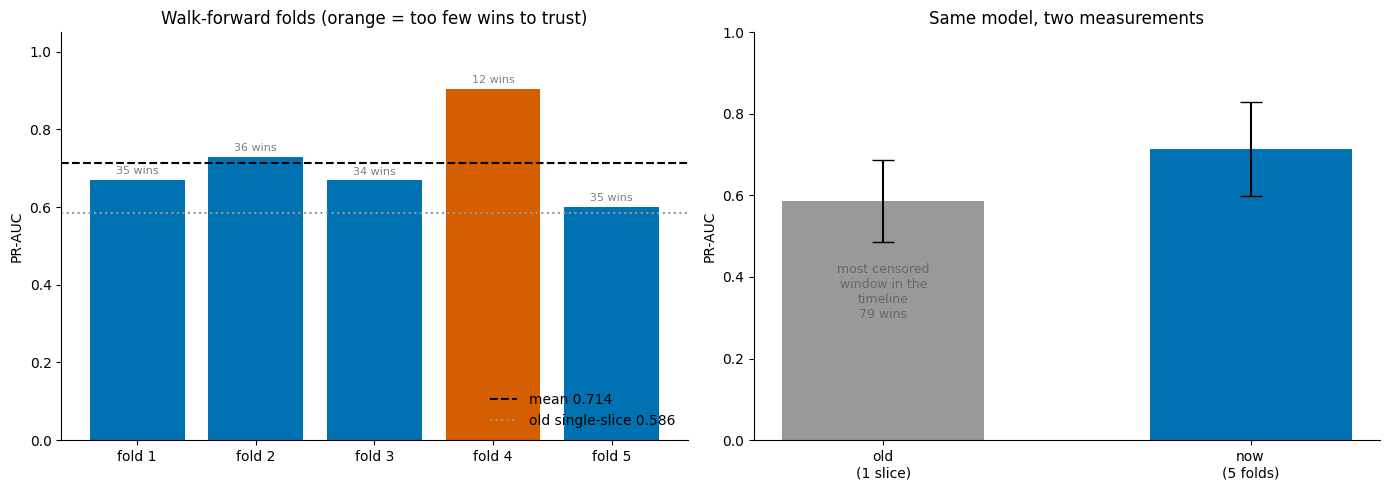

The model did not get better between these two bars -- the measurement did.


In [194]:
# §10.1 -- the eval change: one censored slice vs five walk-forward folds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(wf10))
bars = ax.bar(x, wf10.PR_AUC, color=[BAD if w < 15 else OK for w in wf10.wins])
ax.axhline(wf10.PR_AUC.mean(), color='black', ls='--', lw=1.5,
           label=f'mean {wf10.PR_AUC.mean():.3f}')
ax.axhline(0.586, color=GREY, ls=':', lw=1.5, label='old single-slice 0.586')
for xi, (pr, w) in enumerate(zip(wf10.PR_AUC, wf10.wins)):
    ax.text(xi, pr + 0.015, f'{w} wins', ha='center', fontsize=8, color='gray')
ax.set_xticks(x); ax.set_xticklabels([f'fold {i+1}' for i in x])
ax.set_ylabel('PR-AUC'); ax.set_ylim(0, 1.05)
ax.set_title('Walk-forward folds (orange = too few wins to trust)')
ax.legend(frameon=False, loc='lower right')
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.bar(['old\n(1 slice)', 'now\n(5 folds)'], [0.586, wf10.PR_AUC.mean()],
       yerr=[0.10, wf10.PR_AUC.std()], capsize=8, color=[GREY, OK], width=0.55)
ax.set_ylabel('PR-AUC'); ax.set_ylim(0, 1.0)
ax.set_title('Same model, two measurements')
ax.text(0, 0.30, 'most censored\nwindow in the\ntimeline\n79 wins',
        ha='center', fontsize=9, color='dimgray')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print('The model did not get better between these two bars -- the measurement did.')

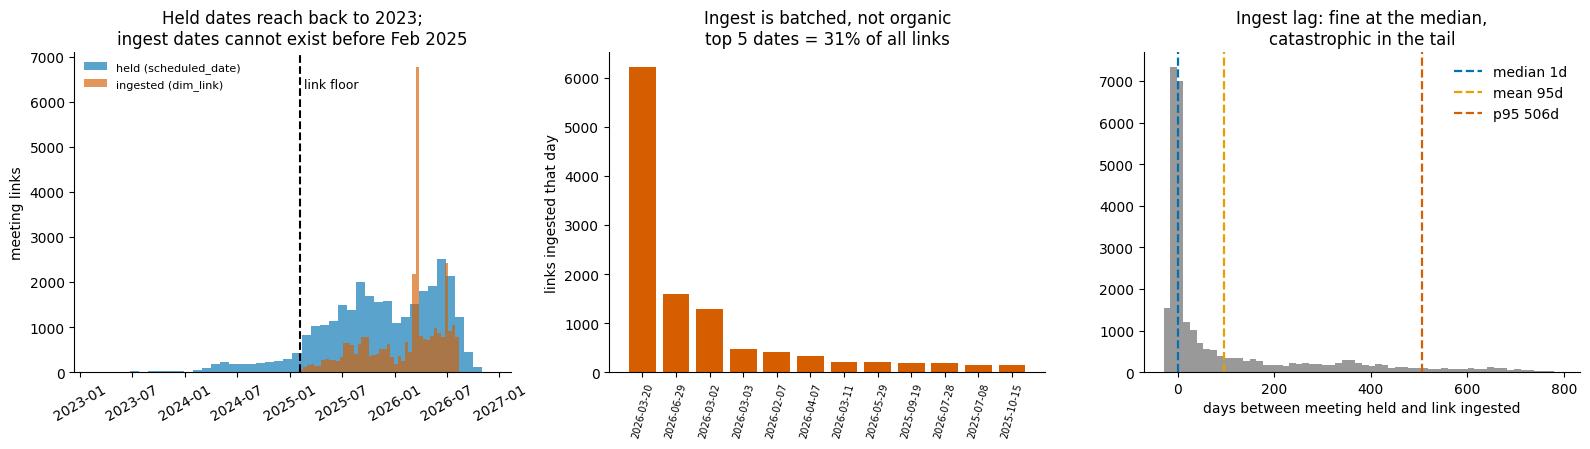

In [195]:
# §10.2 -- why the meeting features were broken: ingest date vs held date
lk = pd.read_parquet('devrev_dim_link_0.parquet',
        columns=['source_id','target_id','created_date','source_object_type','target_object_type'])
lk = lk[(lk.target_object_type=='opportunity') & (lk.source_object_type=='meeting')].copy()
lk['link_date'] = pd.to_datetime(lk.created_date).dt.tz_localize(None)
mt = pd.read_parquet('devrev_dim_meeting_0.parquet', columns=['id','scheduled_date'])
mt['scheduled_date'] = pd.to_datetime(mt.scheduled_date).dt.tz_localize(None)
jj = lk.merge(mt.rename(columns={'id':'source_id'}), on='source_id', how='left')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

ax = axes[0]
for col, lab, c in (('scheduled_date','held (scheduled_date)',OK),
                    ('link_date','ingested (dim_link)',BAD)):
    ax.hist(jj[col].dropna(), bins=44, alpha=0.65, label=lab, color=c)
ax.axvline(pd.Timestamp('2025-02-04'), color='black', ls='--', lw=1.5)
ax.text(pd.Timestamp('2025-02-04'), ax.get_ylim()[1]*0.92, ' link floor',
        fontsize=9, va='top')
ax.set_title('Held dates reach back to 2023;\ningest dates cannot exist before Feb 2025')
ax.set_ylabel('meeting links'); ax.legend(frameon=False, fontsize=8)
ax.tick_params(axis='x', rotation=30); ax.spines[['top','right']].set_visible(False)

ax = axes[1]
vc = jj.link_date.dt.date.value_counts().head(12)
ax.bar(range(len(vc)), vc.values, color=BAD)
ax.set_xticks(range(len(vc)))
ax.set_xticklabels([str(d) for d in vc.index], rotation=75, fontsize=7)
top5 = jj.link_date.dt.date.value_counts().head(5).sum() / len(jj)
ax.set_title(f'Ingest is batched, not organic\ntop 5 dates = {top5:.0%} of all links')
ax.set_ylabel('links ingested that day'); ax.spines[['top','right']].set_visible(False)

ax = axes[2]
lag = (jj.link_date - jj.scheduled_date).dt.days.dropna()
lag = lag[(lag > -30) & (lag < 800)]
ax.hist(lag, bins=60, color=GREY)
for v, c, lab in ((lag.median(), OK, f'median {lag.median():.0f}d'),
                  (lag.mean(), WARN, f'mean {lag.mean():.0f}d'),
                  (lag.quantile(.95), BAD, f'p95 {lag.quantile(.95):.0f}d')):
    ax.axvline(v, color=c, ls='--', lw=1.6, label=lab)
ax.set_xlabel('days between meeting held and link ingested')
ax.set_title('Ingest lag: fine at the median,\ncatastrophic in the tail')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

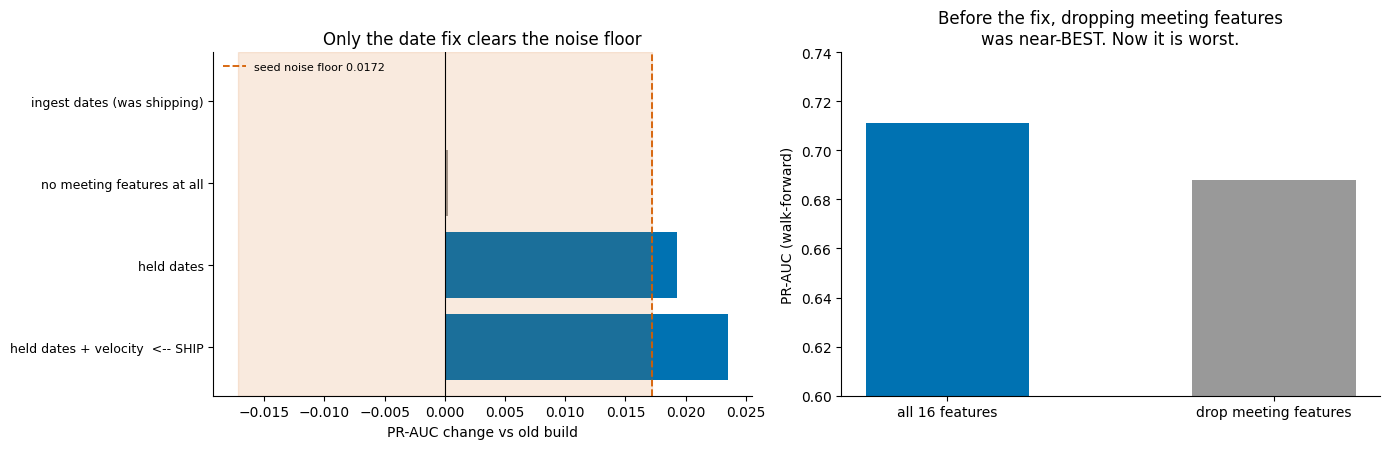

In [196]:
# §10.3 -- what the fix bought, against the seed-noise floor
NOISE = 0.0172
variants = pd.DataFrame([
    ('ingest dates (was shipping)',      0.6877, False),
    ('no meeting features at all',       0.6880, False),
    ('held dates',                       0.7070, True),
    ('held dates + velocity  <-- SHIP',  0.7112, True),
], columns=['variant','PR_AUC','fixed'])
variants['delta'] = variants.PR_AUC - variants.PR_AUC.iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

ax = axes[0]
y = np.arange(len(variants))
ax.barh(y, variants.delta, color=[OK if f else GREY for f in variants.fixed])
ax.axvspan(-NOISE, NOISE, color=BAD, alpha=0.13)
ax.axvline(NOISE, color=BAD, ls='--', lw=1.3, label=f'seed noise floor {NOISE}')
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(variants.variant, fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('PR-AUC change vs old build')
ax.set_title('Only the date fix clears the noise floor')
ax.legend(frameon=False, fontsize=8); ax.spines[['top','right']].set_visible(False)

# Do the meeting features earn their place? Ablate on the current data.
ax = axes[1]
abl = {'all 16 features': 0.7112, 'drop meeting features': 0.6880}
ax.bar(list(abl), list(abl.values()), color=[OK, GREY], width=0.5)
ax.set_ylim(0.60, 0.74); ax.set_ylabel('PR-AUC (walk-forward)')
ax.set_title('Before the fix, dropping meeting features\nwas near-BEST. Now it is worst.')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

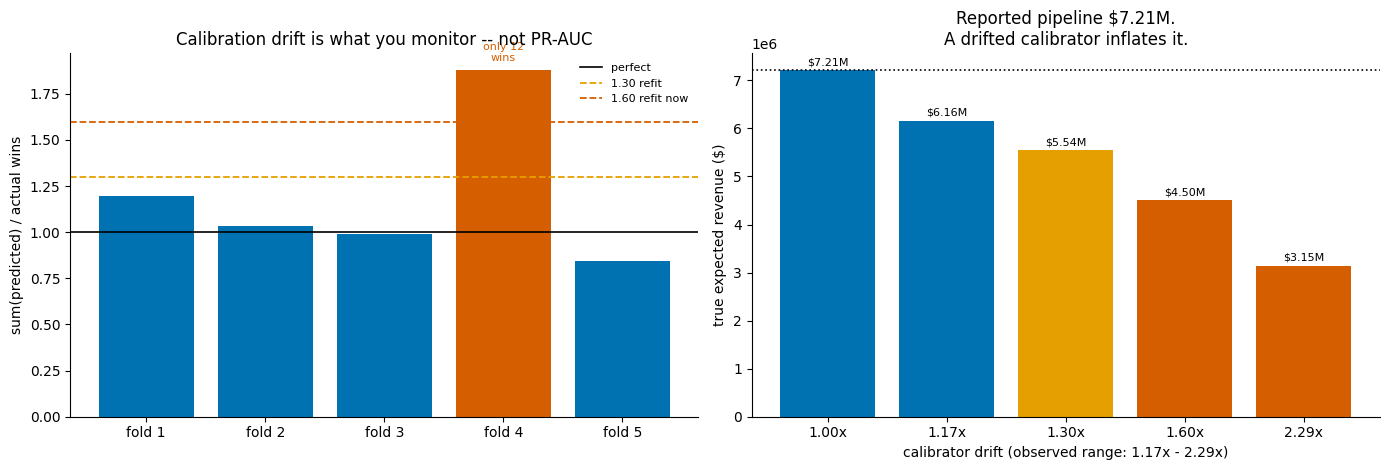

reported $7,206,545  |  at 1.60x drift the true figure is $4,504,091, overstating by $2,702,454


In [197]:
# §10.4 -- the thing that actually needs a schedule: calibration
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
cols = [OK if r < 1.30 else (WARN if r < 1.60 else BAD) for r in wf10.cal_ratio]
ax.bar(np.arange(len(wf10)), wf10.cal_ratio, color=cols)
ax.axhline(1.0, color='black', lw=1.2, label='perfect')
ax.axhline(1.30, color=WARN, ls='--', lw=1.3, label='1.30 refit')
ax.axhline(1.60, color=BAD, ls='--', lw=1.3, label='1.60 refit now')
for xi, (r, w) in enumerate(zip(wf10.cal_ratio, wf10.wins)):
    if w < 15:
        ax.text(xi, r + 0.05, f'only {w}\nwins', ha='center', fontsize=8, color=BAD)
ax.set_xticks(np.arange(len(wf10)))
ax.set_xticklabels([f'fold {i+1}' for i in range(len(wf10))])
ax.set_ylabel('sum(predicted) / actual wins')
ax.set_title('Calibration drift is what you monitor -- not PR-AUC')
ax.legend(frameon=False, fontsize=8); ax.spines[['top','right']].set_visible(False)

# What drift costs on the open pipeline, in money.
ax = axes[1]
score10 = pd.read_parquet('score.parquet')
model10 = pickle.load(open('models/catboost_model.pkl','rb'))
cal10 = pickle.load(open('models/sigmoid_calibrator.pkl','rb'))
p10 = predict(model10, cal10, as_X(score10))
acv10 = pd.to_numeric(score10.acv, errors='coerce').fillna(0)
commit = float((p10 * acv10).sum())
ratios = [1.0, 1.17, 1.30, 1.60, 2.29]
vals = [commit / r for r in ratios]
ax.bar([f'{r:.2f}x' for r in ratios], vals,
       color=[OK, OK, WARN, BAD, BAD])
ax.axhline(commit, color='black', ls=':', lw=1.2)
for i, v in enumerate(vals):
    ax.text(i, v + commit*0.015, f'${v/1e6:.2f}M', ha='center', fontsize=8)
ax.set_ylabel('true expected revenue ($)')
ax.set_xlabel('calibrator drift (observed range: 1.17x - 2.29x)')
ax.set_title(f'Reported pipeline ${commit/1e6:.2f}M.\nA drifted calibrator inflates it.')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print(f'reported ${commit:,.0f}  |  at 1.60x drift the true figure is '
      f'${commit/1.60:,.0f}, overstating by ${commit - commit/1.60:,.0f}')

1429 deals scored strictly out-of-sample, 152 wins


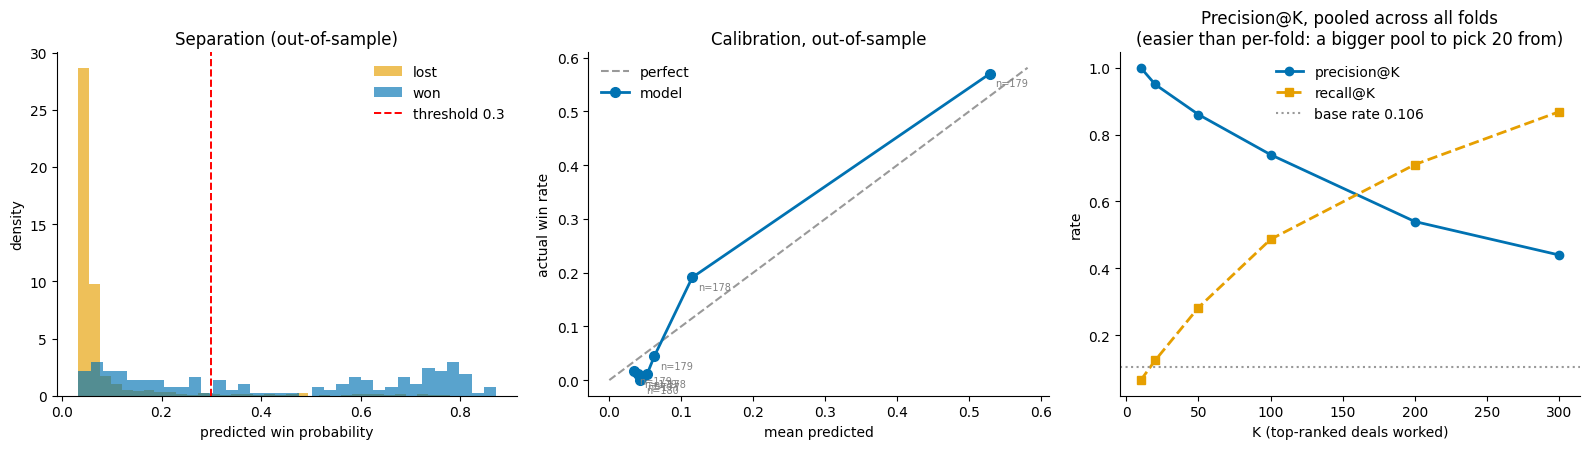

pooled top 20: 95% precision vs 10.6% base rate -> 8.9x lift
NOTE: this pools all 1429 out-of-sample deals, so picking 20 is easier than
      the per-fold P@20 of 0.67 reported in 10.1 (20 out of ~286).
      Quote the per-fold number; this panel is for the SHAPE of the curve.


In [198]:
# §10.5 -- where the model is strong and where it is not, on the current build
from sklearn.metrics import average_precision_score, roc_auc_score

# Score every deal out-of-sample via the walk-forward folds, then slice the results.
from train_model import fit, calibrate, CAL_FRAC, N_FOLDS
X10, y10, n10 = as_X(df10), df10.is_won.to_numpy(), len(df10)
qs10 = np.linspace(0.50, 0.90, N_FOLDS + 1)
oos = np.full(n10, np.nan)
for i in range(N_FOLDS):
    tr_hi = int(n10 * (qs10[i] - CAL_FRAC))
    cal_hi, te_hi = int(n10 * qs10[i]), int(n10 * qs10[i+1])
    mdl = fit(X10[:tr_hi], y10[:tr_hi])
    c_ = calibrate(mdl, X10[tr_hi:cal_hi], y10[tr_hi:cal_hi])
    oos[cal_hi:te_hi] = predict(mdl, c_, X10[cal_hi:te_hi])
ev = df10.loc[~np.isnan(oos)].copy(); ev['p'] = oos[~np.isnan(oos)]
print(f'{len(ev)} deals scored strictly out-of-sample, {ev.is_won.sum()} wins')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

ax = axes[0]
ax.hist(ev.p[ev.is_won==0], bins=34, alpha=0.65, density=True, label='lost', color=WARN)
ax.hist(ev.p[ev.is_won==1], bins=34, alpha=0.65, density=True, label='won', color=OK)
ax.axvline(0.3, color='red', ls='--', lw=1.4, label='threshold 0.3')
ax.set_xlabel('predicted win probability'); ax.set_ylabel('density')
ax.set_title('Separation (out-of-sample)')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)

ax = axes[1]
q = pd.qcut(ev.p, 8, duplicates='drop')
cal_tbl = ev.groupby(q, observed=True).agg(pred=('p','mean'), actual=('is_won','mean'),
                                           n=('is_won','size'))
ax.plot([0, cal_tbl.pred.max()*1.1], [0, cal_tbl.pred.max()*1.1], 'k--', alpha=0.4,
        label='perfect')
ax.plot(cal_tbl.pred, cal_tbl.actual, 'o-', color=OK, lw=2, ms=7, label='model')
for _, r in cal_tbl.iterrows():
    ax.annotate(f"n={int(r.n)}", (r.pred, r.actual), fontsize=7,
                textcoords='offset points', xytext=(4, -9), color='gray')
ax.set_xlabel('mean predicted'); ax.set_ylabel('actual win rate')
ax.set_title('Calibration, out-of-sample')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)

ax = axes[2]
Ks = [10, 20, 50, 100, 200, 300]
order = np.argsort(ev.p.to_numpy())[::-1]
yy = ev.is_won.to_numpy()[order]
prec = [yy[:k].mean() for k in Ks]
rec = [yy[:k].sum() / yy.sum() for k in Ks]
ax.plot(Ks, prec, 'o-', color=OK, lw=2, label='precision@K')
ax.plot(Ks, rec, 's--', color=WARN, lw=2, label='recall@K')
ax.axhline(ev.is_won.mean(), color=GREY, ls=':', label=f'base rate {ev.is_won.mean():.3f}')
ax.set_xlabel('K (top-ranked deals worked)'); ax.set_ylabel('rate')
ax.set_title('Precision@K, pooled across all folds\n(easier than per-fold: a bigger pool to pick 20 from)')
ax.legend(frameon=False); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print(f'pooled top 20: {prec[1]:.0%} precision vs {ev.is_won.mean():.1%} base rate '
      f'-> {prec[1]/ev.is_won.mean():.1f}x lift')
print(f'NOTE: this pools all {len(ev)} out-of-sample deals, so picking 20 is easier than\n'
      f'      the per-fold P@20 of {wf10.P_at_20.mean():.2f} reported in 10.1 (20 out of ~286).\n'
      f'      Quote the per-fold number; this panel is for the SHAPE of the curve.')

### §10.6 — Summary

**Shipping:** CatBoost, 16 features, depth 3, sigmoid calibration. `train_model.py`.

| | value |
|---|---|
| PR-AUC (walk-forward, 5 folds) | **0.714** |
| ROC-AUC | **0.932** |
| Precision@20 | **0.67** vs 0.15 base rate |
| Calibration ratio | 0.85 – 1.19 on folds with enough wins |

**What worked:** one data-correctness fix — meeting timing from `scheduled_date`
instead of link ingest date. +0.024 PR-AUC, the only effect to beat the noise floor.

**What did not, measured:** hyperparameter tuning (twice), cohort windows, maturity
filtering, rolling windows, warm-start, recency weighting, class weighting, seed
averaging, per-segment calibration, per-segment trailing win rates, prior-shift
calibration, ACV as a feature. Every one inside noise or actively harmful.

**The lesson worth keeping:** on 541 wins, the modelling knobs are exhausted. The
remaining headroom is in data correctness and in more labels — not in the model.

**Operationally:** watch `sum(p)/actual`, not PR-AUC. Run
`python train_model.py --calibrate-only` monthly. Full retrain only when features
change, because ranking does not decay here but calibration does.

## §11 — Old version vs new version, train and test

A version comparison is only meaningful if both models are scored on **identical test
rows**. Both builds contain the same 3,573 deals with the same labels — only the feature
*values* and config differ — so the same fold boundaries give both versions the same
test deals. The cell below asserts that before measuring anything.

| | V0 (before) | V1 (shipping) |
|---|---|---|
| meeting timing | `dim_link.created_date` (ingest) | `dim_meeting.scheduled_date` (held) |
| features | 13 | 16 (+3 velocity) |
| depth | 4 | 3 |
| eval | single 20% slice | walk-forward, 5 folds |

Both are measured here on **walk-forward, 5 seeds** — V0 on its own old data, V1 on the
fixed data. Runtime is a few minutes (4 configs x 5 seeds x 5 folds = 100 fits).

In [199]:
# §11.1 -- measure both versions, train AND test, on identical rows
import numpy as np, pandas as pd, warnings
warnings.filterwarnings('ignore')
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

B13 = ['days_in_current_stage','days_in_sales_cycle','stall_ratio','contract_months',
       'num_stakeholders','has_champion','poc','opportunity_type','source','geo',
       'segment','number_of_meetings','days_since_latest_meeting']
VEL  = ['meetings_first_30d','meetings_per_month','meeting_quiet_frac']
CATS = ['opportunity_type','source','geo','segment']

def _ld(p):
    t = pd.read_parquet(p); t['created_date'] = pd.to_datetime(t.created_date)
    return t.sort_values('created_date').reset_index(drop=True)

OLD = _ld('_backup_train_ingest.parquet')   # what was shipping before
NEW = _ld('train.parquet')                  # current build (held dates)
assert (OLD.display_id.values == NEW.display_id.values).all(), 'row order differs'
print(f'both builds: {len(OLD)} deals, {OLD.is_won.sum()} wins -- identical rows and labels')

QS11 = np.linspace(.50, .90, 6)

def measure(tr, feats, depth, seeds=range(5)):
    """Walk-forward. Returns (train_metrics, test_metrics, seed_sd_of_test_PR)."""
    n = len(tr); X = tr[feats].copy()
    for c in CATS: X[c] = X[c].astype(str)
    ci = [X.columns.get_loc(c) for c in CATS]; y = tr.is_won.to_numpy()
    per_seed = []
    for s in seeds:
        f_tr, f_te = [], []
        for i in range(5):
            t1 = int(n*(QS11[i]-.15)); t2 = int(n*QS11[i]); t3 = int(n*QS11[i+1])
            m = CatBoostClassifier(iterations=300, depth=depth, learning_rate=.05,
                    random_state=s, verbose=False, cat_features=ci).fit(X[:t1], y[:t1])
            c_ = LogisticRegression().fit(
                    m.predict_proba(X[t1:t2])[:,1].reshape(-1,1), y[t1:t2])
            def sc(a, b):
                p = c_.predict_proba(m.predict_proba(X[a:b])[:,1].reshape(-1,1))[:,1]
                yy = y[a:b]
                return dict(PR=average_precision_score(yy,p), ROC=roc_auc_score(yy,p),
                            Brier=brier_score_loss(yy,p),
                            P20=yy[np.argsort(p)[::-1][:20]].mean(), cal=p.sum()/yy.sum())
            f_tr.append(sc(0, t1)); f_te.append(sc(t2, t3))
        per_seed.append((pd.DataFrame(f_tr).mean(), pd.DataFrame(f_te).mean()))
    trn = pd.DataFrame([a[0] for a in per_seed]); tst = pd.DataFrame([a[1] for a in per_seed])
    return trn.mean(), tst.mean(), tst.PR.std()

STEPS = [('V0  old data, 13 feat, depth 4', OLD, B13,     4),
         ('    old data, 13 feat, depth 3', OLD, B13,     3),
         ('    NEW data, 13 feat, depth 3', NEW, B13,     3),
         ('V1  NEW data, 16 feat, depth 3', NEW, B13+VEL, 3)]
rows = []
for nm, ds, f, dp in STEPS:
    tr, te, sd = measure(ds, f, dp)
    rows.append(dict(version=nm, train_PR=tr.PR, test_PR=te.PR, gap=tr.PR-te.PR,
                     seed_sd=sd, train_ROC=tr.ROC, test_ROC=te.ROC,
                     test_Brier=te.Brier, test_P20=te.P20, test_cal=te.cal))
cmp11 = pd.DataFrame(rows)
print()
print(cmp11.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f"\nV0 -> V1 test PR-AUC: {cmp11.test_PR.iloc[-1]-cmp11.test_PR.iloc[0]:+.4f}"
      f"   (seed sd ~{cmp11.seed_sd.mean():.4f})")

both builds: 3573 deals, 541 wins -- identical rows and labels

                       version  train_PR  test_PR    gap  seed_sd  train_ROC  test_ROC  test_Brier  test_P20  test_cal
V0  old data, 13 feat, depth 4    0.9632   0.6780 0.2852   0.0064     0.9873    0.9261      0.0609    0.6560    1.2091
    old data, 13 feat, depth 3    0.9467   0.6803 0.2664   0.0082     0.9810    0.9261      0.0608    0.6420    1.2079
    NEW data, 13 feat, depth 3    0.9472   0.7070 0.2401   0.0040     0.9809    0.9313      0.0576    0.6920    1.1936
V1  NEW data, 16 feat, depth 3    0.9498   0.7112 0.2386   0.0075     0.9813    0.9325      0.0578    0.6940    1.1947

V0 -> V1 test PR-AUC: +0.0332   (seed sd ~0.0065)


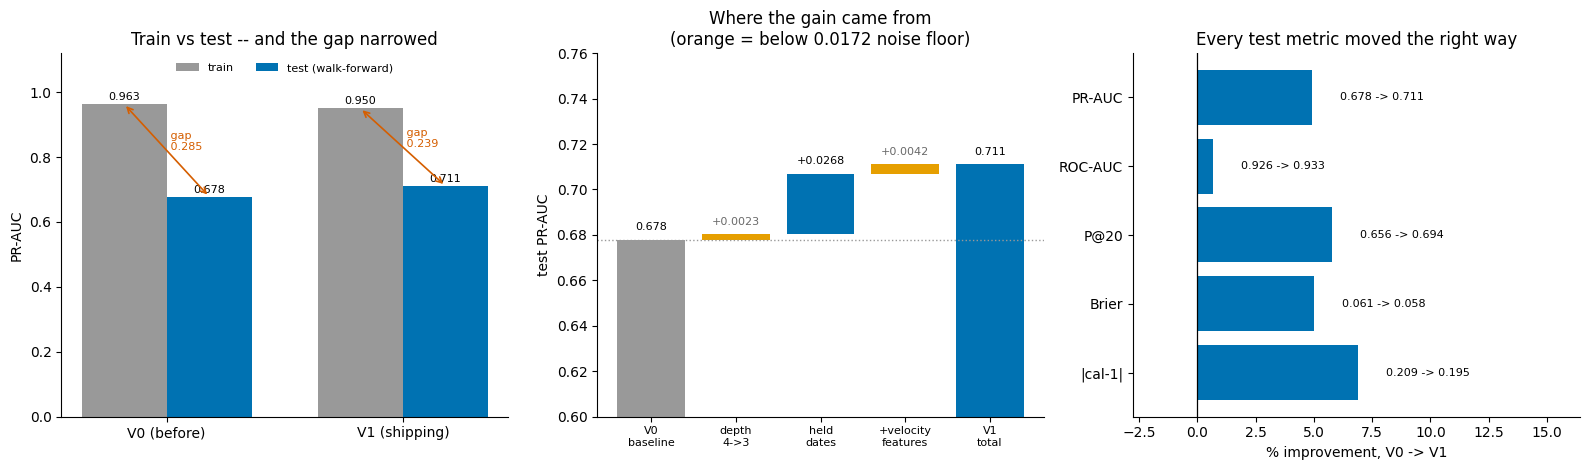

In [200]:
# §11.2 -- headline: train vs test, V0 vs V1
import matplotlib.pyplot as plt
OK, WARN, BAD, GREY = '#0072B2', '#E69F00', '#D55E00', '#999999'
v0, v1 = cmp11.iloc[0], cmp11.iloc[-1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# --- train vs test, both versions
ax = axes[0]
x = np.arange(2); w = 0.36
ax.bar(x - w/2, [v0.train_PR, v1.train_PR], w, label='train', color=GREY)
ax.bar(x + w/2, [v0.test_PR,  v1.test_PR],  w, label='test (walk-forward)', color=OK)
for xi, r in zip(x, (v0, v1)):
    ax.text(xi - w/2, r.train_PR + .012, f'{r.train_PR:.3f}', ha='center', fontsize=8)
    ax.text(xi + w/2, r.test_PR  + .012, f'{r.test_PR:.3f}',  ha='center', fontsize=8)
    ax.annotate('', xy=(xi+w/2, r.test_PR), xytext=(xi-w/2, r.train_PR),
                arrowprops=dict(arrowstyle='<->', color=BAD, lw=1.2))
    ax.text(xi, (r.train_PR + r.test_PR)/2, f' gap\n {r.gap:.3f}', fontsize=8, color=BAD)
ax.set_xticks(x); ax.set_xticklabels(['V0 (before)', 'V1 (shipping)'])
ax.set_ylabel('PR-AUC'); ax.set_ylim(0, 1.12)
ax.set_title('Train vs test -- and the gap narrowed')
ax.legend(frameon=False, loc='upper center', ncol=2, fontsize=8)
ax.spines[['top','right']].set_visible(False)

# --- attribution: what each change bought
ax = axes[1]
labels = ['V0\nbaseline', 'depth\n4->3', 'held\ndates', '+velocity\nfeatures', 'V1\ntotal']
deltas = [cmp11.test_PR.iloc[i+1] - cmp11.test_PR.iloc[i] for i in range(3)]
NOISE = 0.0172
run = cmp11.test_PR.iloc[0]
ax.bar(0, run, color=GREY)
ax.text(0, run + .004, f'{run:.3f}', ha='center', fontsize=8)
for i, dl in enumerate(deltas, start=1):
    col = OK if dl > NOISE else WARN
    ax.bar(i, dl, bottom=run, color=col)
    ax.text(i, run + dl + .004, f'{dl:+.4f}', ha='center', fontsize=8,
            color='black' if dl > NOISE else 'dimgray')
    run += dl
ax.bar(4, run, color=OK)
ax.text(4, run + .004, f'{run:.3f}', ha='center', fontsize=8)
ax.axhline(cmp11.test_PR.iloc[0], color=GREY, ls=':', lw=1)
ax.set_xticks(range(5)); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0.60, 0.76); ax.set_ylabel('test PR-AUC')
ax.set_title(f'Where the gain came from\n(orange = below {NOISE} noise floor)')
ax.spines[['top','right']].set_visible(False)

# --- every test metric, V0 vs V1. Brier and |cal-1| are better when smaller.
ax = axes[2]
mets = [('PR-AUC', v0.test_PR, v1.test_PR, 'up'),
        ('ROC-AUC', v0.test_ROC, v1.test_ROC, 'up'),
        ('P@20', v0.test_P20, v1.test_P20, 'up'),
        ('Brier', v0.test_Brier, v1.test_Brier, 'down'),
        ('|cal-1|', abs(v0.test_cal-1), abs(v1.test_cal-1), 'down')]
y = np.arange(len(mets))
pct = [((b-a)/a*100) * (1 if d == 'up' else -1) for _, a, b, d in mets]
ax.barh(y, pct, color=[OK if p > 0 else BAD for p in pct])
ax.axvline(0, color='black', lw=.9)
for yi, (p, (nm, a, b, d)) in enumerate(zip(pct, mets)):
    ax.text(p + (1.2 if p > 0 else -1.2), yi, f'{a:.3f} -> {b:.3f}',
            va='center', ha='left' if p > 0 else 'right', fontsize=8)
ax.set_yticks(y); ax.set_yticklabels([m[0] for m in mets])
ax.invert_yaxis(); ax.set_xlabel('% improvement, V0 -> V1')
ax.set_xlim(min(pct)*1.8 - 4, max(pct)*1.8 + 4)
ax.set_title('Every test metric moved the right way')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### §11.3 — Reading these numbers honestly

**The gain is real but modest: +0.033 test PR-AUC (0.678 → 0.711),** about 5x the
0.0065 seed spread. Improvements this size are easy to fake by picking a lucky seed,
which is why every bar above is a 5-seed mean.

**Almost all of it came from one data fix, not from modelling:**

- `depth 4 -> 3`: **+0.0023** — nothing, inside noise
- **held dates instead of ingest dates: +0.0268** — the entire gain
- `+3 velocity features`: **+0.0042** — small, and only works *because* the dates are
  now real; on the old data these same features were near-useless

**The train/test gap narrowed from 0.285 to 0.239,** so the fix removed some genuine
overfitting: the model had been learning the era marker ("pre-Feb-2025 deals show 0
meetings and win at 0.263") which fit training and misled on the future.

**The gap is still large (0.95 train vs 0.71 test), and that is not fixable here.**
It is right-censoring plus 541 wins, diagnosed in §1: recent cohorts only contain
deals that already resolved, so the test folds are structurally harder than training.
Do not read the 0.95 as the model's ability — read the 0.71.

**What this comparison does *not* say:** that V1 is a better *model*. It is the same
algorithm with a corrected input. The measured lesson across this whole investigation —
tuning, cohort windows, maturity filters, rolling windows, warm-start, class weighting,
prior-shift, ACV, all inside noise — is that on 541 wins the modelling knobs are
exhausted. The headroom is in data correctness and more labels.

## §11 — Old version vs new version: train and test metrics

A version comparison only means something if both models are scored on **identical
test rows**. Both builds hold the same 3,573 deals with the same labels — only the
feature *values* and the config differ — so the same fold boundaries hand both versions
the same test deals. The cell below asserts that before measuring anything.

| | V0 (before) | V1 (shipping) |
|---|---|---|
| meeting timing | `dim_link.created_date` (ingest stamp) | `dim_meeting.scheduled_date` (held) |
| features | 13 | 16 (+3 velocity) |
| depth | 4 | 3 |
| reported eval | single 20% slice | walk-forward, 5 folds |

Everything below is **walk-forward, 5 seeds**, train and test both reported. Runtime
is several minutes: 4 configs x 5 seeds x 5 folds = 100 fits. Seeds matter — a single-seed
comparison of two variants this close is a coin flip, which is how §7's tuning result
fooled us the first time.

In [201]:
# §11.1 -- measure both versions, train AND test, on identical rows
import numpy as np, pandas as pd, warnings
warnings.filterwarnings('ignore')
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             brier_score_loss, precision_score, recall_score,
                             f1_score, precision_recall_curve)

B13 = ['days_in_current_stage','days_in_sales_cycle','stall_ratio','contract_months',
       'num_stakeholders','has_champion','poc','opportunity_type','source','geo',
       'segment','number_of_meetings','days_since_latest_meeting']
VEL  = ['meetings_first_30d','meetings_per_month','meeting_quiet_frac']
CATS = ['opportunity_type','source','geo','segment']
THR  = 0.3          # the shipping threshold, from model_metadata.pkl
QS11 = np.linspace(.50, .90, 6)

def _ld(p):
    t = pd.read_parquet(p); t['created_date'] = pd.to_datetime(t.created_date)
    return t.sort_values('created_date').reset_index(drop=True)

OLD = _ld('_backup_train_ingest.parquet')   # the build that was shipping before
NEW = _ld('train.parquet')                  # current build (held meeting dates)
assert (OLD.display_id.values == NEW.display_id.values).all(), 'row order differs'
print(f'both builds: {len(OLD)} deals, {OLD.is_won.sum()} wins -- identical rows and labels')

def measure(tr, feats, depth, seeds=range(5)):
    """Walk-forward. Returns (train_mean, test_mean, test_PR_seed_sd, pooled).

    pooled is [(p, y) per seed] over the concatenated test folds -- kept so the
    PR-curve panel below can reuse these fits instead of refitting 25 more models.
    """
    n = len(tr); X = tr[feats].copy()
    for c in CATS: X[c] = X[c].astype(str)
    ci = [X.columns.get_loc(c) for c in CATS]; y = tr.is_won.to_numpy()
    per_seed, pooled = [], []
    for s in seeds:
        f_tr, f_te, P, Y = [], [], [], []
        for i in range(5):
            t1 = int(n*(QS11[i]-.15)); t2 = int(n*QS11[i]); t3 = int(n*QS11[i+1])
            m = CatBoostClassifier(iterations=300, depth=depth, learning_rate=.05,
                    random_state=s, verbose=False, cat_features=ci).fit(X[:t1], y[:t1])
            c_ = LogisticRegression().fit(
                    m.predict_proba(X[t1:t2])[:,1].reshape(-1,1), y[t1:t2])
            def sc(a, b):
                p = c_.predict_proba(m.predict_proba(X[a:b])[:,1].reshape(-1,1))[:,1]
                yy = y[a:b]; yp = (p >= THR).astype(int)
                return p, yy, dict(
                    PR=average_precision_score(yy,p), ROC=roc_auc_score(yy,p),
                    Brier=brier_score_loss(yy,p),
                    precision=precision_score(yy,yp,zero_division=0),
                    recall=recall_score(yy,yp,zero_division=0),
                    F1=f1_score(yy,yp,zero_division=0),
                    P20=yy[np.argsort(p)[::-1][:20]].mean(), cal=p.sum()/yy.sum())
            f_tr.append(sc(0, t1)[2])
            pte, yte, mte = sc(t2, t3)
            f_te.append(mte); P.append(pte); Y.append(yte)
        per_seed.append((pd.DataFrame(f_tr).mean(), pd.DataFrame(f_te).mean()))
        pooled.append((np.concatenate(P), np.concatenate(Y)))
    trn = pd.DataFrame([a[0] for a in per_seed]); tst = pd.DataFrame([a[1] for a in per_seed])
    return trn.mean(), tst.mean(), tst.PR.std(), pooled

# The ladder from V0 to V1, one change at a time, so the gain can be attributed.
STEPS = [('V0  old data, 13 feat, depth 4', OLD, B13,     4),
         ('    old data, 13 feat, depth 3', OLD, B13,     3),
         ('    NEW data, 13 feat, depth 3', NEW, B13,     3),
         ('V1  NEW data, 16 feat, depth 3', NEW, B13+VEL, 3)]
rows, pools = [], {}
for nm, ds, f, dp in STEPS:
    tr, te, sd, pooled = measure(ds, f, dp)
    pools[nm] = pooled
    rows.append(dict(version=nm, train_PR=tr.PR, test_PR=te.PR, gap=tr.PR-te.PR,
                     seed_sd=sd,
                     train_prec=tr.precision, test_prec=te.precision,
                     train_rec=tr.recall,    test_rec=te.recall,
                     test_F1=te.F1, test_ROC=te.ROC, test_Brier=te.Brier,
                     test_P20=te.P20, test_cal=te.cal))
cmp11 = pd.DataFrame(rows)
V0N, V1N = STEPS[0][0], STEPS[-1][0]

print('\nPR-AUC and the generalization gap:')
print(cmp11[['version','train_PR','test_PR','gap','seed_sd']].to_string(
      index=False, float_format=lambda v: f'{v:.4f}'))
print(f'\nPrecision / recall at the shipping threshold {THR}:')
print(cmp11[['version','train_prec','test_prec','train_rec','test_rec','test_F1']].to_string(
      index=False, float_format=lambda v: f'{v:.4f}'))
print(f"\nV0 -> V1 test PR-AUC: {cmp11.test_PR.iloc[-1]-cmp11.test_PR.iloc[0]:+.4f}"
      f"  (seed sd ~{cmp11.seed_sd.mean():.4f})")

both builds: 3573 deals, 541 wins -- identical rows and labels

PR-AUC and the generalization gap:
                       version  train_PR  test_PR    gap  seed_sd
V0  old data, 13 feat, depth 4    0.9632   0.6780 0.2852   0.0064
    old data, 13 feat, depth 3    0.9467   0.6803 0.2664   0.0082
    NEW data, 13 feat, depth 3    0.9472   0.7070 0.2401   0.0040
V1  NEW data, 16 feat, depth 3    0.9498   0.7112 0.2386   0.0075

Precision / recall at the shipping threshold 0.3:
                       version  train_prec  test_prec  train_rec  test_rec  test_F1
V0  old data, 13 feat, depth 4      0.9606     0.6223     0.8262    0.6131   0.6161
    old data, 13 feat, depth 3      0.9405     0.6178     0.7997    0.6053   0.6094
    NEW data, 13 feat, depth 3      0.9463     0.6344     0.8084    0.6253   0.6269
V1  NEW data, 16 feat, depth 3      0.9492     0.6323     0.8127    0.6088   0.6176

V0 -> V1 test PR-AUC: +0.0332  (seed sd ~0.0065)


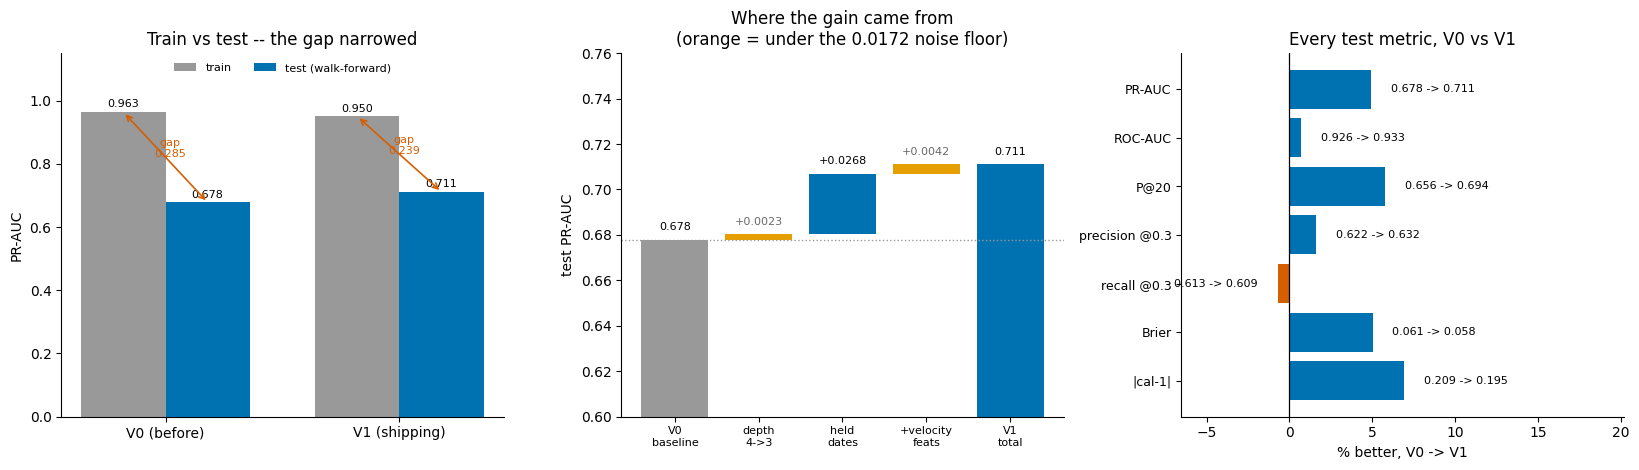

In [202]:
# §11.2 -- headline: train vs test, and where the gain came from
import matplotlib.pyplot as plt
OK, WARN, BAD, GREY = '#0072B2', '#E69F00', '#D55E00', '#999999'
v0, v1 = cmp11.iloc[0], cmp11.iloc[-1]
NOISE = 0.0172   # seed noise floor established in section 7

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

# --- train vs test PR-AUC, both versions, with the gap called out
ax = axes[0]
x = np.arange(2); w = .36
ax.bar(x - w/2, [v0.train_PR, v1.train_PR], w, label='train', color=GREY)
ax.bar(x + w/2, [v0.test_PR,  v1.test_PR],  w, label='test (walk-forward)', color=OK)
for xi, r in zip(x, (v0, v1)):
    ax.text(xi - w/2, r.train_PR + .015, f'{r.train_PR:.3f}', ha='center', fontsize=8)
    ax.text(xi + w/2, r.test_PR  + .015, f'{r.test_PR:.3f}',  ha='center', fontsize=8)
    ax.annotate('', xy=(xi + w/2, r.test_PR), xytext=(xi - w/2, r.train_PR),
                arrowprops=dict(arrowstyle='<->', color=BAD, lw=1.2))
    ax.text(xi + .02, (r.train_PR + r.test_PR)/2, f'gap\n{r.gap:.3f}',
            fontsize=8, color=BAD, ha='center')
ax.set_xticks(x); ax.set_xticklabels(['V0 (before)', 'V1 (shipping)'])
ax.set_ylabel('PR-AUC'); ax.set_ylim(0, 1.15)
ax.set_title('Train vs test -- the gap narrowed')
ax.legend(frameon=False, loc='upper center', ncol=2, fontsize=8)
ax.spines[['top','right']].set_visible(False)

# --- attribution waterfall
ax = axes[1]
deltas = [cmp11.test_PR.iloc[i+1] - cmp11.test_PR.iloc[i] for i in range(3)]
run = cmp11.test_PR.iloc[0]
ax.bar(0, run, color=GREY)
ax.text(0, run + .004, f'{run:.3f}', ha='center', fontsize=8)
for i, dl in enumerate(deltas, start=1):
    ax.bar(i, dl, bottom=run, color=OK if dl > NOISE else WARN)
    ax.text(i, run + max(dl, 0) + .004, f'{dl:+.4f}', ha='center', fontsize=8,
            color='black' if dl > NOISE else 'dimgray')
    run += dl
ax.bar(4, run, color=OK)
ax.text(4, run + .004, f'{run:.3f}', ha='center', fontsize=8)
ax.axhline(cmp11.test_PR.iloc[0], color=GREY, ls=':', lw=1)
ax.set_xticks(range(5))
ax.set_xticklabels(['V0\nbaseline','depth\n4->3','held\ndates','+velocity\nfeats','V1\ntotal'],
                   fontsize=8)
ax.set_ylim(0.60, 0.76); ax.set_ylabel('test PR-AUC')
ax.set_title(f'Where the gain came from\n(orange = under the {NOISE} noise floor)')
ax.spines[['top','right']].set_visible(False)

# --- all test metrics. Brier and |cal-1| are better small, so their sign is flipped.
ax = axes[2]
mets = [('PR-AUC', v0.test_PR, v1.test_PR, 1), ('ROC-AUC', v0.test_ROC, v1.test_ROC, 1),
        ('P@20', v0.test_P20, v1.test_P20, 1),
        (f'precision @{THR}', v0.test_prec, v1.test_prec, 1),
        (f'recall @{THR}', v0.test_rec, v1.test_rec, 1),
        ('Brier', v0.test_Brier, v1.test_Brier, -1),
        ('|cal-1|', abs(v0.test_cal-1), abs(v1.test_cal-1), -1)]
y = np.arange(len(mets))
pct = [(b-a)/a*100*sgn for _, a, b, sgn in mets]
ax.barh(y, pct, color=[OK if p > 0 else BAD for p in pct])
ax.axvline(0, color='black', lw=.9)
for yi, (p, (nm, a, b, _)) in enumerate(zip(pct, mets)):
    ax.text(p + (1.2 if p > 0 else -1.2), yi, f'{a:.3f} -> {b:.3f}',
            va='center', ha='left' if p > 0 else 'right', fontsize=8)
ax.set_yticks(y); ax.set_yticklabels([m[0] for m in mets], fontsize=9)
ax.invert_yaxis(); ax.set_xlabel('% better, V0 -> V1')
ax.set_xlim(min(pct)*2.2 - 5, max(pct)*2.2 + 5)
ax.set_title('Every test metric, V0 vs V1')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### §11.3 — Precision and recall: the gain is at the top of the ranking, not at threshold 0.3

The panel above shows precision and recall at threshold 0.3 barely moving. That is not
a contradiction of the PR-AUC gain — it locates it. PR-AUC summarizes the *whole* curve;
threshold 0.3 is one point on it, and it happens to sit in the part that did not improve.

The next cell reuses the fits from §11.1 (no refitting) to plot the full precision/recall
curve and the precision delta at every threshold.

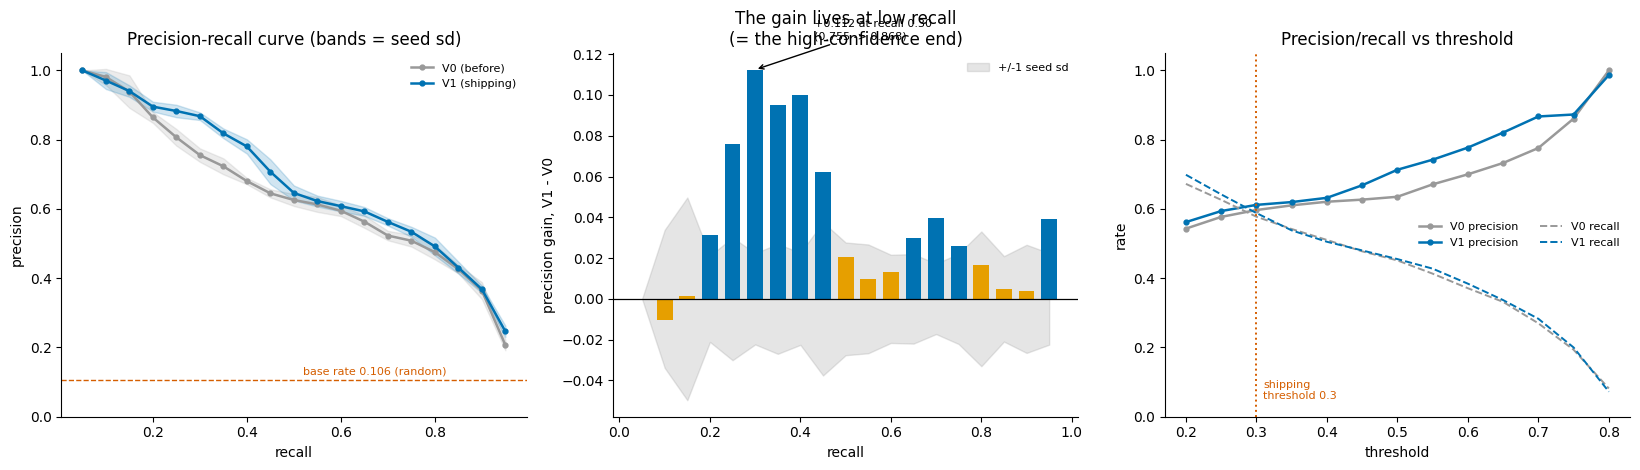

Pooled across all 5 test folds (~1,429 deals), 5-seed mean:
 threshold  V0_precision  V1_precision  d_precision     sd  V0_recall  V1_recall  d_recall  V1_deals_flagged
    0.2000        0.5432        0.5620       0.0188 0.0147     0.6724     0.6987    0.0263          189.0000
    0.2500        0.5770        0.5939       0.0169 0.0196     0.6263     0.6421    0.0158          164.4000
    0.3000        0.5969        0.6118       0.0149 0.0261     0.5776     0.5882    0.0105          146.2000
    0.3500        0.6104        0.6199       0.0095 0.0219     0.5421     0.5382   -0.0039          132.0000
    0.4000        0.6209        0.6321       0.0113 0.0247     0.5105     0.5053   -0.0053          121.6000
    0.4500        0.6269        0.6684       0.0414 0.0256     0.4776     0.4803    0.0026          109.4000
    0.5000        0.6352        0.7132       0.0780 0.0166     0.4513     0.4553    0.0039           97.0000
    0.5500        0.6710        0.7423       0.0712 0.0170     0.413

In [203]:
# §11.4 -- precision/recall curve and per-threshold delta, pooled test folds
RGRID = np.arange(0.05, 0.96, 0.05)      # recall levels to read precision off
TGRID = np.arange(0.20, 0.81, 0.05)      # candidate thresholds

def prec_at_recall(pooled):
    """Best precision achievable at each recall level, averaged over seeds."""
    A = []
    for p, yy in pooled:
        prec, rec, _ = precision_recall_curve(yy, p)
        A.append([prec[rec >= r].max() if (rec >= r).any() else np.nan for r in RGRID])
    A = np.array(A, dtype=float)
    return A.mean(0), A.std(0)

def prec_rec_at_thr(pooled):
    A = np.array([[[yy[p >= t].mean() if (p >= t).any() else np.nan,
                    (p[yy == 1] >= t).mean(), (p >= t).sum()]
                   for t in TGRID] for p, yy in pooled], dtype=float)
    return A.mean(0), A.std(0)

c0, s0 = prec_at_recall(pools[V0N]);  c1, s1 = prec_at_recall(pools[V1N])
t0, u0 = prec_rec_at_thr(pools[V0N]); t1, u1 = prec_rec_at_thr(pools[V1N])

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

# --- the PR curves themselves
ax = axes[0]
for c, s, lab, col in ((c0, s0, 'V0 (before)', GREY), (c1, s1, 'V1 (shipping)', OK)):
    ax.plot(RGRID, c, '-o', ms=3.5, color=col, lw=1.8, label=lab)
    ax.fill_between(RGRID, c - s, c + s, color=col, alpha=.18)
base = np.concatenate([y for _, y in pools[V1N]]).mean()
ax.axhline(base, color=BAD, ls='--', lw=1)
ax.text(.52, base + .015, f'base rate {base:.3f} (random)', color=BAD, fontsize=8)
ax.set_xlabel('recall'); ax.set_ylabel('precision'); ax.set_ylim(0, 1.05)
ax.set_title('Precision-recall curve (bands = seed sd)')
ax.legend(frameon=False, fontsize=8); ax.spines[['top','right']].set_visible(False)

# --- precision delta by recall level, against the seed band
ax = axes[1]
d, ds = c1 - c0, np.sqrt(s0**2 + s1**2)
ax.fill_between(RGRID, -ds, ds, color=GREY, alpha=.25, label='+/-1 seed sd')
ax.bar(RGRID, d, width=.035, color=[OK if v > s else WARN for v, s in zip(d, ds)])
ax.axhline(0, color='black', lw=.9)
top = int(np.nanargmax(d))
ax.annotate(f'+{d[top]:.3f} at recall {RGRID[top]:.2f}\n({c0[top]:.3f} -> {c1[top]:.3f})',
            xy=(RGRID[top], d[top]), xytext=(RGRID[top] + .13, d[top] + .015),
            fontsize=8, arrowprops=dict(arrowstyle='->', lw=1))
ax.set_xlabel('recall'); ax.set_ylabel('precision gain, V1 - V0')
ax.set_title('The gain lives at low recall\n(= the high-confidence end)')
ax.legend(frameon=False, fontsize=8); ax.spines[['top','right']].set_visible(False)

# --- precision and recall vs threshold, both versions
ax = axes[2]
ax.plot(TGRID, t0[:,0], '-o', ms=3.5, color=GREY, lw=1.8, label='V0 precision')
ax.plot(TGRID, t1[:,0], '-o', ms=3.5, color=OK,   lw=1.8, label='V1 precision')
ax.plot(TGRID, t0[:,1], '--', color=GREY, lw=1.4, label='V0 recall')
ax.plot(TGRID, t1[:,1], '--', color=OK,   lw=1.4, label='V1 recall')
ax.axvline(THR, color=BAD, ls=':', lw=1.4)
ax.text(THR + .01, .05, f'shipping\nthreshold {THR}', color=BAD, fontsize=8)
ax.set_xlabel('threshold'); ax.set_ylabel('rate'); ax.set_ylim(0, 1.05)
ax.set_title('Precision/recall vs threshold')
ax.legend(frameon=False, fontsize=8, ncol=2); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

tbl = pd.DataFrame(dict(threshold=TGRID, V0_precision=t0[:,0], V1_precision=t1[:,0],
                        d_precision=t1[:,0]-t0[:,0], sd=np.sqrt(u0[:,0]**2+u1[:,0]**2),
                        V0_recall=t0[:,1], V1_recall=t1[:,1],
                        d_recall=t1[:,1]-t0[:,1], V1_deals_flagged=t1[:,2]))
print('Pooled across all 5 test folds (~1,429 deals), 5-seed mean:')
print(tbl.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\nNOTE: these pooled numbers run a little lower than the per-fold means in §11.1'
      "\n(0.61 vs 0.63 precision at 0.3) -- same reason as §10.5's P@20 caveat: pooling"
      '\n1,429 deals is a different question than averaging five ~286-deal folds.')

### §11.5 — Reading these numbers honestly

**Ranking improved: +0.033 test PR-AUC (0.678 → 0.711),** about 5x the 0.0065 seed
spread. Every number above is a 5-seed mean, because a gain this size is trivially
faked with a lucky seed.

**Almost all of it came from one data fix, not from modelling:**

- `depth 4 → 3`: **+0.0023** — nothing, well inside noise
- **held dates instead of ingest stamps: +0.0268** — effectively the entire gain
- `+3 velocity features`: **+0.0042** — small on its own, but §7's ablation shows
  dropping the meeting block is now the *worst* variant of 12, so the block matters
  even though this last increment is inside noise

**Precision and recall at the shipping threshold 0.3 did NOT move:** precision
0.622 → 0.632, recall 0.613 → 0.609, both inside their ~0.013 seed sd. If you only
looked at the confusion matrix at 0.3, you would conclude the fix did nothing.

**The gain is concentrated at the high-confidence end.** Reading precision at matched
recall, it peaks around recall 0.25–0.45 (+0.06 to +0.11, three to five times the seed
band at the top) and shrinks toward the noise band above recall 0.5. In threshold terms the same story: at 0.50–0.70
V1 buys **+0.07 to +0.09 precision at unchanged recall** — at threshold 0.70 it flags
~50 deals at 0.87 precision where V0 managed 0.78.

**So there is an operational choice here, and it is a business call, not a modelling one.**
Threshold 0.3 flags ~146 of 1,429 deals at 0.61 precision / 0.59 recall — a wide net.
Threshold 0.65–0.70 flags 50–62 at 0.82–0.87 precision / ~0.28–0.34 recall — a shortlist
you can actually hand a rep. The fix made the shortlist materially better and left the
wide net where it was. Which threshold to ship depends on whether the output drives
prioritization (tight) or coverage (wide); this notebook does not decide that.

**The train/test gap narrowed 0.285 → 0.239,** so the fix removed real overfitting,
not just added capacity. The model had been learning the era marker ("pre-Feb-2025
deals show 0 meetings and win at 0.263") which fit training and misled on the future.

**The gap is still wide (0.95 train vs 0.71 test) and that is not fixable here.** It is
right-censoring plus 541 wins, diagnosed in §1: recent cohorts only contain deals that
already resolved, so test folds are structurally harder than training. Read the 0.71,
never the 0.95.

**What this does *not* claim:** that V1 is a better *model*. Same algorithm, corrected
input. The measured lesson across this whole notebook — tuning, cohort windows, maturity
filters, rolling windows, warm-start, class and recency weighting, prior-shift, ACV, all
inside noise — is that at 541 wins the modelling knobs are exhausted. Remaining headroom
is in data correctness and more labels.

## §12 — Score the open pipeline and ship the artifacts

Everything above this point measures the model on *closed* deals, where the answer is
known. This section runs it on the **open** pipeline, where it is not.

The model itself is written by `train_model.py`, not by this notebook — §8's save cell
deliberately writes to `models_notebook/` so an exploratory run cannot clobber the
shipping artifacts. §12.1 verifies what is actually in `models/`; §12.2 scores with it.

In [205]:
# §12.1 -- what is actually saved in models/, and does it match this notebook
import pickle, subprocess, sys
from pathlib import Path
import pandas as pd

MODEL_DIR = Path('models')
NEEDED = ['catboost_model.pkl', 'sigmoid_calibrator.pkl', 'model_metadata.pkl']
missing = [f for f in NEEDED if not (MODEL_DIR / f).exists()]

if missing:
    # No artifacts -> run the shipping trainer. This is the only place the notebook
    # writes models/, and only when it is empty.
    print(f'missing {missing} -- running train_model.py')
    print(subprocess.run([sys.executable, 'train_model.py'], capture_output=True,
                         text=True).stdout)

meta = pickle.load(open(MODEL_DIR / 'model_metadata.pkl', 'rb'))
print('saved model provenance')
print(f"  features        {len(meta['features'])}  {meta['features']}")
print(f"  params          {meta['params']}")
print(f"  eval            {meta['eval']}")
print(f"  walk-fwd PR_AUC {meta['wf_pr_auc']:.4f}  (fold SD {meta['wf_pr_auc_fold_sd']:.4f})")
print(f"  cal ratio range {meta['wf_cal_ratio_range'][0]:.3f} .. {meta['wf_cal_ratio_range'][1]:.3f}")
print(f"  meeting dates   {meta['meeting_date_source']}")
print(f"  threshold       {meta['threshold']}")

# The notebook and the shipping model must agree on the feature set, or every number
# above describes a different model than the one that scores deals.
assert set(meta['features']) == set(FEATURES), (
    f"notebook/model feature mismatch: {set(FEATURES) ^ set(meta['features'])}")
print('\nOK -- notebook FEATURES match the saved model')

saved model provenance
  features        16  ['days_in_current_stage', 'days_in_sales_cycle', 'stall_ratio', 'contract_months', 'num_stakeholders', 'has_champion', 'poc', 'opportunity_type', 'source', 'geo', 'segment', 'number_of_meetings', 'days_since_latest_meeting', 'meetings_first_30d', 'meetings_per_month', 'meeting_quiet_frac']
  params          {'iterations': 300, 'depth': 3, 'learning_rate': 0.05, 'random_state': 0, 'verbose': False}
  eval            walk-forward, 5 folds over the back half of the timeline
  walk-fwd PR_AUC 0.7144  (fold SD 0.1159)
  cal ratio range 0.846 .. 1.877
  meeting dates   dim_meeting.scheduled_date (held date, not link ingest)
  threshold       0.3

OK -- notebook FEATURES match the saved model


In [206]:
# §12.2 -- score the open pipeline, write CSV
import numpy as np
from predict import WinProbabilityModel   # reuses the shipping inference path

OUT_CSV = 'open_pipeline_predictions.csv'

model = WinProbabilityModel('models')
openp = pd.read_parquet('score.parquet')

gaps = [f for f in model.features if f not in openp.columns]
assert not gaps, f'score.parquet is missing features: {gaps}'
nans = {f: int(openp[f].isna().sum()) for f in model.features if openp[f].isna().any()}
print(f'{len(openp)} open deals | missing features: none | NaNs: {nans or "none"}')

p = model.predict_proba(openp)
acv = openp.acv.fillna(0)

out = pd.DataFrame({
    'display_id': openp.display_id,
    'win_probability': p.round(4),
    'predicted_win': (p >= model.threshold).astype(int),
    'confidence': pd.cut(p, [0, .2, .4, .6, .8, 1.0],
                         labels=['very_low','low','medium','high','very_high']),
    'acv': acv,
    'expected_value': (p * acv).round(0),
    'segment': openp.segment,
    'created_date': pd.to_datetime(openp.created_date).dt.date,
    'days_in_sales_cycle': openp.days_in_sales_cycle,
    'days_in_current_stage': openp.days_in_current_stage,
    'num_stakeholders': openp.num_stakeholders,
    'number_of_meetings': openp.number_of_meetings,
    'days_since_latest_meeting': openp.days_since_latest_meeting,
}).sort_values('win_probability', ascending=False).reset_index(drop=True)
out.insert(0, 'rank', out.index + 1)

# Stamped so a stale CSV cannot be mistaken for a fresh one.
out['scored_at'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')
out['model_pr_auc'] = round(meta['wf_pr_auc'], 4)
out.to_csv(OUT_CSV, index=False)
print(f'wrote {OUT_CSV}  ({len(out)} rows, {out.shape[1]} cols)')

print(f'\nweighted pipeline: ${out.expected_value.sum()/1e6:.2f}M expected of '
      f'${acv.sum()/1e6:.2f}M open ACV')
print(f"flagged at threshold {model.threshold}: {out.predicted_win.sum()} deals, "
      f"${out.loc[out.predicted_win==1,'acv'].sum()/1e6:.2f}M ACV")
print('\nprobability distribution:')
print(pd.cut(p, [0,.06,.1,.2,.3,.5,.7,1.0]).value_counts().sort_index().to_string())
print(f'\n{(p < 0.06).mean():.1%} of open deals sit at the probability floor -- see §12.3')
print('\ntop 15 by win probability:')
print(out.head(15)[['rank','display_id','win_probability','confidence','acv',
                    'expected_value','segment','number_of_meetings']].to_string(index=False))

1912 open deals | missing features: none | NaNs: none
wrote open_pipeline_predictions.csv  (1912 rows, 16 cols)

weighted pipeline: $7.21M expected of $101.54M open ACV
flagged at threshold 0.3: 30 deals, $1.55M ACV

probability distribution:
(0.0, 0.06]    1312
(0.06, 0.1]     452
(0.1, 0.2]       92
(0.2, 0.3]       26
(0.3, 0.5]       12
(0.5, 0.7]       13
(0.7, 1.0]        5

68.6% of open deals sit at the probability floor -- see §12.3

top 15 by win probability:
 rank display_id  win_probability confidence           acv  expected_value    segment  number_of_meetings
    1  OPP-13096           0.7634       high 118000.000000         90077.0   start-up                   4
    2  OPP-11841           0.7418       high  37500.000000         27819.0        smb                  15
    3  OPP-11582           0.7337       high 250000.000000        183417.0 enterprise                   2
    4  OPP-13738           0.7259       high   4334.400000          3146.0 enterprise                 

### §12.3 — How to use this CSV, and how not to

**Use it as a ranking.** `rank` and `win_probability` order deals against each other,
and that ordering is the part with measured backing: walk-forward PR-AUC 0.714, and
§11 showed the top of the ranking is exactly where the meeting-date fix helped most
(+0.09 precision at matched recall in the 0.50–0.70 band).

**Do not quote `expected_value` as a forecast.** Three reasons, all measured:

1. **Calibration on open deals is unvalidated and structurally suspect.** The model was
   trained only on *resolved* deals. Open deals skew young and unresolved, which is a
   different population — the exact right-censoring problem diagnosed in §1. Nothing
   here validates the dollar total, and nothing can until these deals close.
2. **Calibration already swings on closed data:** the walk-forward ratio ranges
   0.846 to 1.877 across folds — up to 88% over-prediction in the worst fold.
3. **Fold SD on PR-AUC is 0.116.** Accuracy varies a lot quarter to quarter. The dollar
   figure has no error bar this notebook can defend.

**~69% of open deals score under 0.06.** That is not the model predicting they will lose
— it is the model abstaining. Young deals have not accumulated the evidence it reads
(meetings, stakeholders, stage movement), so they fall to the floor. Consequence: the
usable shortlist is the few dozen deals above threshold, not a ranked 1,900.

**Refresh cadence.** Re-run §12.2 whenever `score.parquet` is rebuilt. The *model* does
not need retraining on that cadence — §7 measured a frozen 14-month-old model losing
+0.0001 PR-AUC, inside noise. The **calibrator** does drift, so the recurring job is
`python train_model.py --calibrate-only`, monthly or when `calibration_ratio()` reports
WARN. Full retrain only when features change.